In [173]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf # for neural network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical


In [174]:
df= pd.read_csv('academic_success_dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Marital status                  4001 non-null   float64
 1   Application mode                3941 non-null   float64
 2   Application order               3998 non-null   float64
 3   Course                          3959 non-null   float64
 4   Daytime/evening attendance	     3984 non-null   float64
 5   Previous qualification          3990 non-null   float64
 6   Previous qualification (grade)  3952 non-null   float64
 7   Nacionality                     3978 non-null   float64
 8   Mother's qualification          4010 non-null   float64
 9   Father's qualification          3974 non-null   float64
 10  Mother's occupation             3988 non-null   float64
 11  Father's occupation             3999 non-null   float64
 12  Admission grade                 39

In [175]:
df.isnull()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Unemployment rate,Inflation rate,GDP,Target,Unnamed: 25,Unnamed: 26
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,True
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
2,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True
3,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,True,True
4,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,True
4420,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
4421,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,True
4422,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,True


In [176]:
df.isnull().sum()

,0
Marital status,423
Application mode,483
Application order,426
Course,465
Daytime/evening attendance\t,440
Previous qualification,434
Previous qualification (grade),472
Nacionality,446
Mother's qualification,414
Father's qualification,450


In [177]:
df.fillna(0,inplace=True)


In [178]:
df.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance\t,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


In [180]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import warnings as wr # for Handle Error
le=LabelEncoder()
wr.filterwarnings('ignore')
for col in df.columns:
    if df[col].dtype==np.number:
        continue
    df[col] = df[col].astype(str)
    df[col]=le.fit_transform(df[col])
df

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Unemployment rate,Inflation rate,GDP,Target,Unnamed: 25,Unnamed: 26
0,1.0,17.0,5.0,171.0,1.0,1.0,122.0,1.0,19.0,12.0,5.0,9.0,127.3,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,10.8,1.4,1.74,1,0.0,0.0
1,1.0,15.0,1.0,9254.0,1.0,1.0,160.0,1.0,1.0,3.0,3.0,3.0,142.5,1.0,0.0,0.0,0.0,1.0,0.0,19.0,0.0,13.9,-0.3,0.79,3,0.0,0.0
2,1.0,0.0,5.0,9070.0,1.0,1.0,122.0,0.0,37.0,37.0,0.0,9.0,124.8,1.0,0.0,0.0,0.0,1.0,0.0,19.0,0.0,10.8,1.4,1.74,1,0.0,0.0
3,1.0,17.0,2.0,9773.0,1.0,1.0,122.0,1.0,38.0,37.0,5.0,0.0,119.6,1.0,0.0,0.0,1.0,0.0,0.0,20.0,0.0,9.4,-0.8,-3.12,3,0.0,0.0
4,2.0,39.0,1.0,8014.0,0.0,1.0,100.0,1.0,37.0,0.0,9.0,9.0,141.5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,13.9,-0.3,0.79,3,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,0.0,1.0,6.0,9773.0,1.0,1.0,125.0,1.0,1.0,1.0,5.0,4.0,122.2,0.0,0.0,0.0,1.0,1.0,0.0,19.0,0.0,0.0,2.8,-4.06,0,0.0,0.0
4420,1.0,1.0,2.0,9773.0,1.0,1.0,120.0,105.0,1.0,1.0,0.0,9.0,119.0,1.0,0.0,1.0,0.0,0.0,0.0,18.0,1.0,11.1,0.6,2.02,1,0.0,0.0
4421,1.0,1.0,1.0,9500.0,1.0,1.0,154.0,1.0,37.0,37.0,9.0,9.0,149.5,0.0,0.0,0.0,1.0,0.0,1.0,30.0,0.0,13.9,-0.3,0.79,1,0.0,0.0
4422,1.0,1.0,1.0,9147.0,1.0,1.0,180.0,1.0,37.0,37.0,7.0,4.0,153.8,1.0,0.0,0.0,1.0,0.0,1.0,20.0,0.0,9.4,-0.8,-3.12,3,0.0,0.0


DataFrame Head:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Unemployment rate,Inflation rate,GDP,Target,Unnamed: 25,Unnamed: 26
0,1.0,17.0,5.0,171.0,1.0,1.0,122.0,1.0,19.0,12.0,5.0,9.0,127.3,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,10.8,1.4,1.74,1,0.0,0.0
1,1.0,15.0,1.0,9254.0,1.0,1.0,160.0,1.0,1.0,3.0,3.0,3.0,142.5,1.0,0.0,0.0,0.0,1.0,0.0,19.0,0.0,13.9,-0.3,0.79,3,0.0,0.0
2,1.0,0.0,5.0,9070.0,1.0,1.0,122.0,0.0,37.0,37.0,0.0,9.0,124.8,1.0,0.0,0.0,0.0,1.0,0.0,19.0,0.0,10.8,1.4,1.74,1,0.0,0.0


DataFrame Tail:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Unemployment rate,Inflation rate,GDP,Target,Unnamed: 25,Unnamed: 26
4421,1.0,1.0,1.0,9500.0,1.0,1.0,154.0,1.0,37.0,37.0,9.0,9.0,149.5,0.0,0.0,0.0,1.0,0.0,1.0,30.0,0.0,13.9,-0.3,0.79,1,0.0,0.0
4422,1.0,1.0,1.0,9147.0,1.0,1.0,180.0,1.0,37.0,37.0,7.0,4.0,153.8,1.0,0.0,0.0,1.0,0.0,1.0,20.0,0.0,9.4,-0.8,-3.12,3,0.0,0.0
4423,1.0,10.0,1.0,9773.0,1.0,1.0,152.0,22.0,38.0,37.0,5.0,9.0,152.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,1.0,12.7,3.7,-1.70,3,0.0,0.0


----------------------------------------------------------------------------------------------------
Missing values:


,0


----------------------------------------------------------------------------------------------------
Shape of DataFrame:

(4424, 27)

----------------------------------------------------------------------------------------------------
DataFrame Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Marital status                  4424 non-null   float64
 1   Application mode                4424 non-null   float64
 2   Application order               4424 non-null   float64
 3   Course                          4424 non-null   float64
 4   Daytime/evening attendance	     4424 non-null   float64
 5   Previous qualification          4424 non-null   float64
 6   Previous qualification (grade)  4424 non-null   float64
 7   Nacionality                     4424 non-null   float64
 8   Mother's qualification    

,count,mean,median,std,min,25%,50%,75%,max,skewness,kurtosis
Marital status,4424,1.06,1,0.654,0,1,1,1,6,2.826199,14.146227
Application mode,4424,16.535,16,17.46,0,1,16,39,57,0.572718,-1.301718
Application order,4424,1.564,1,1.347,0,1,1,2,9,1.728254,2.597436
Course,4424,7925.722,9238,3344.976,0,9070,9238,9500,9991,-1.894479,1.683862
Daytime/evening attendance,4424,0.804,1,0.397,0,1,1,1,1,-1.528186,0.335354
Previous qualification,4424,4.082,1,9.717,0,1,1,1,43,3.092749,8.177480
Previous qualification (grade),4424,118.533,131,42.833,0,120,131,140,190,-2.136931,3.369119
Nacionality,4424,1.673,1,6.7,0,1,1,1,109,11.477273,152.883028
Mother's qualification,4424,17.659,19,15.917,0,1,19,37,44,0.182764,-1.688001
Father's qualification,4424,19.945,19,16.05,0,1,19,37,44,-0.074895,-1.719435


----------------------------------------------------------------------------------------------------
DataFrame Correlation:



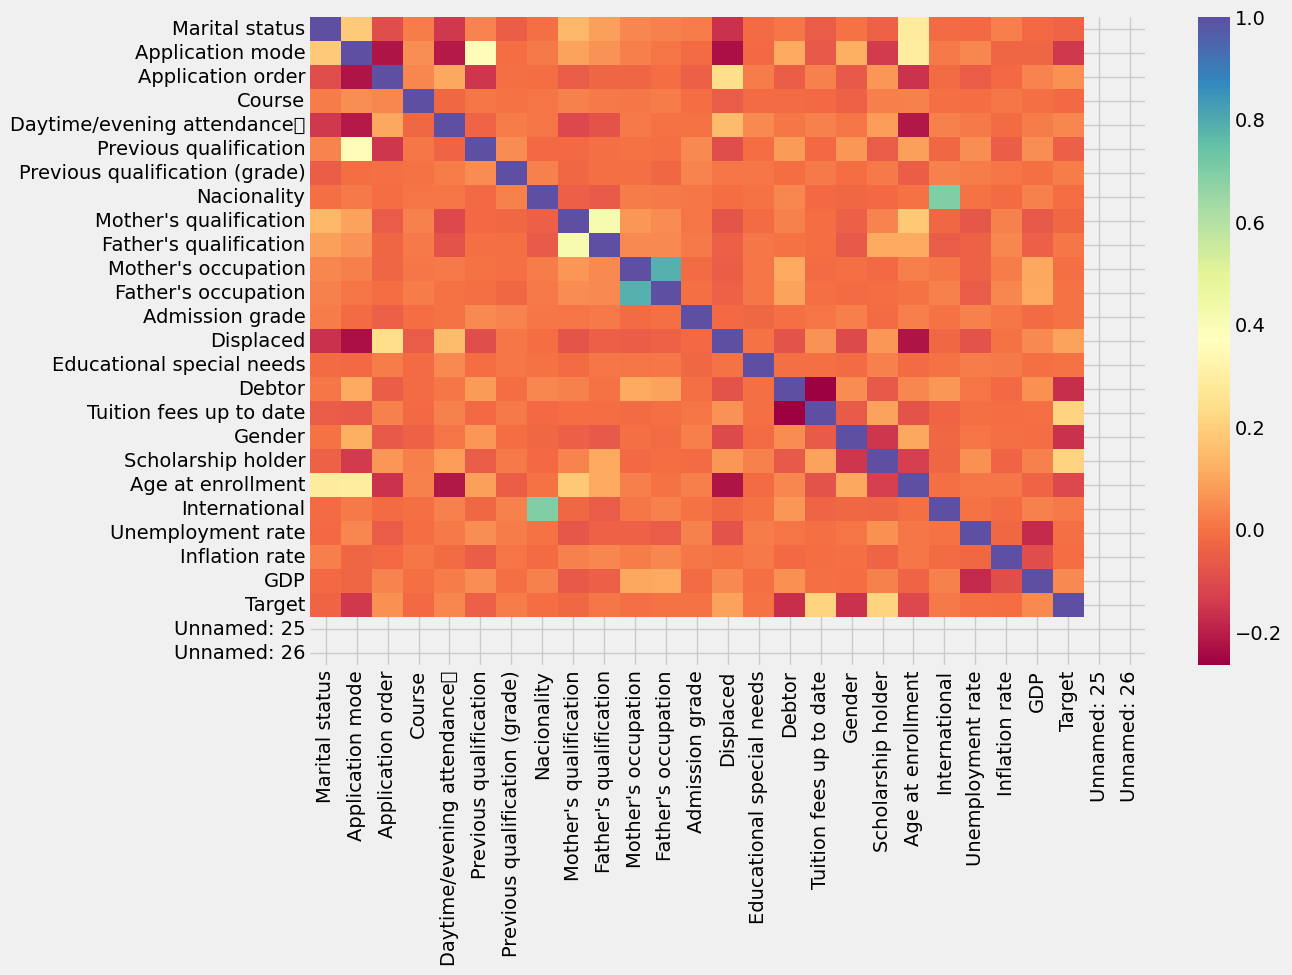

----------------------------------------------------------------------------------------------------
Histogram(s) & Boxplot(s):



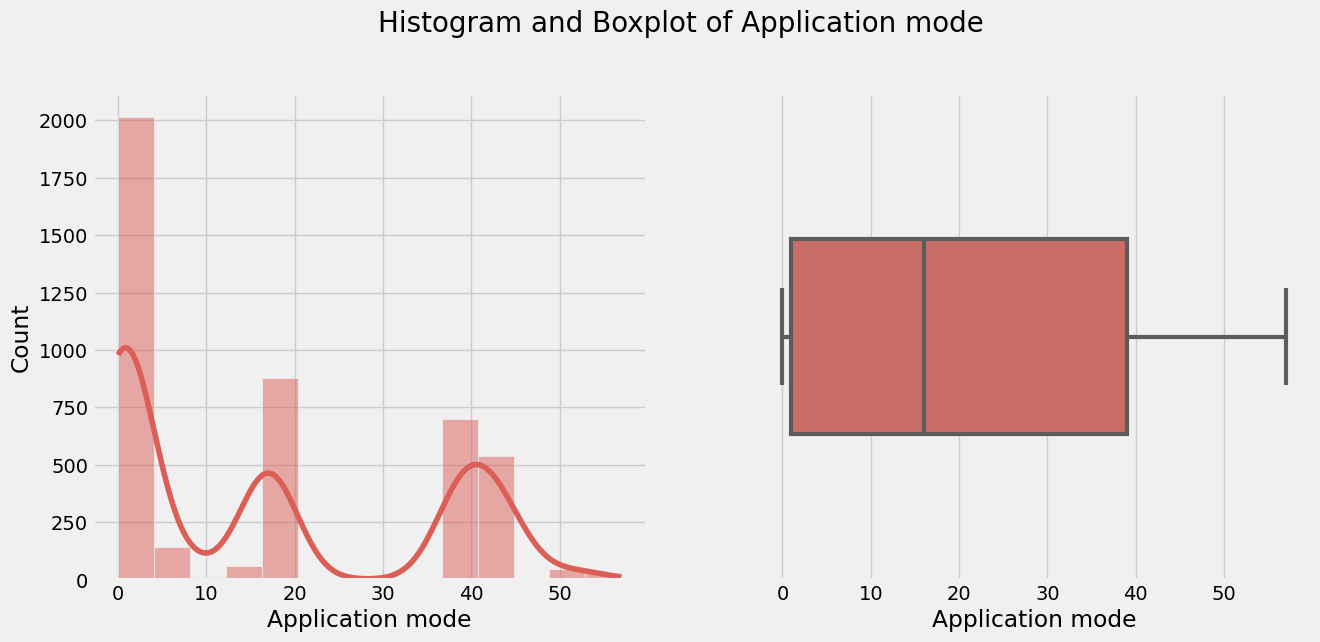

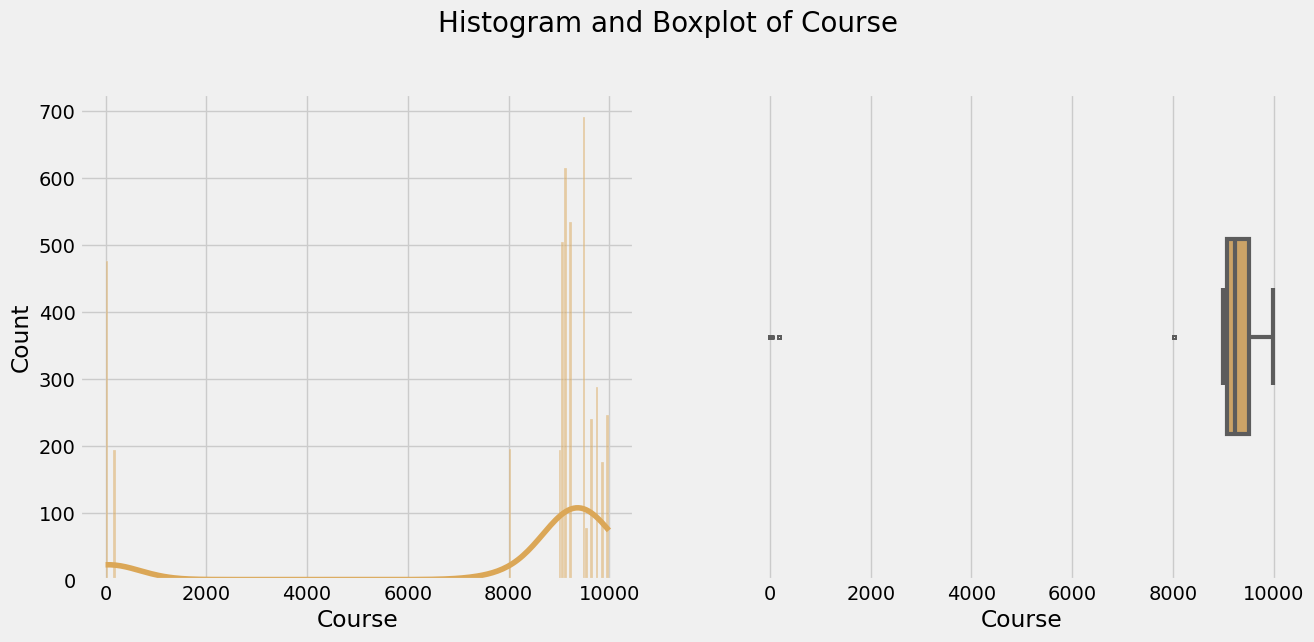

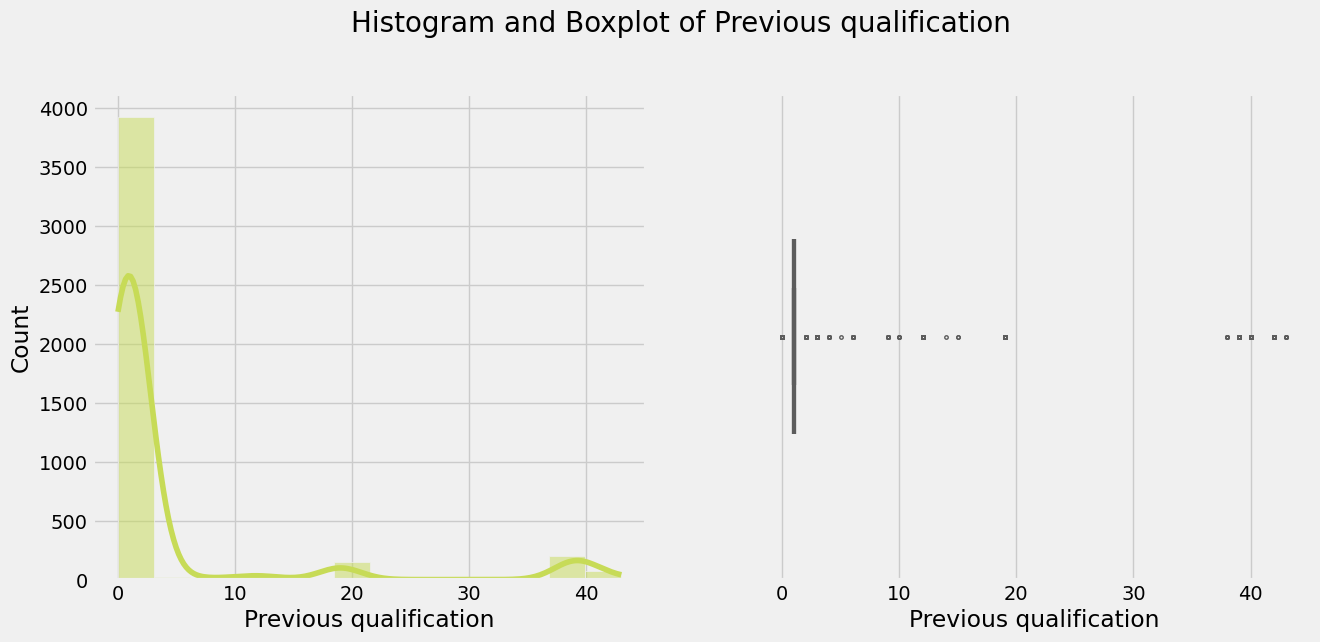

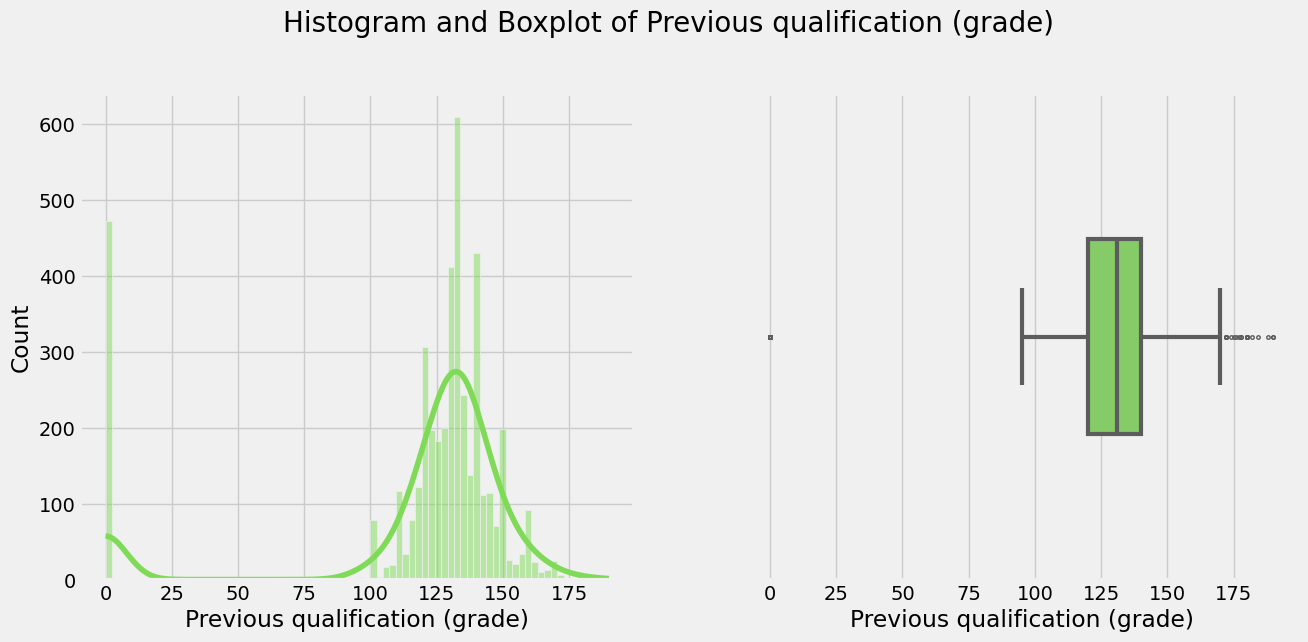

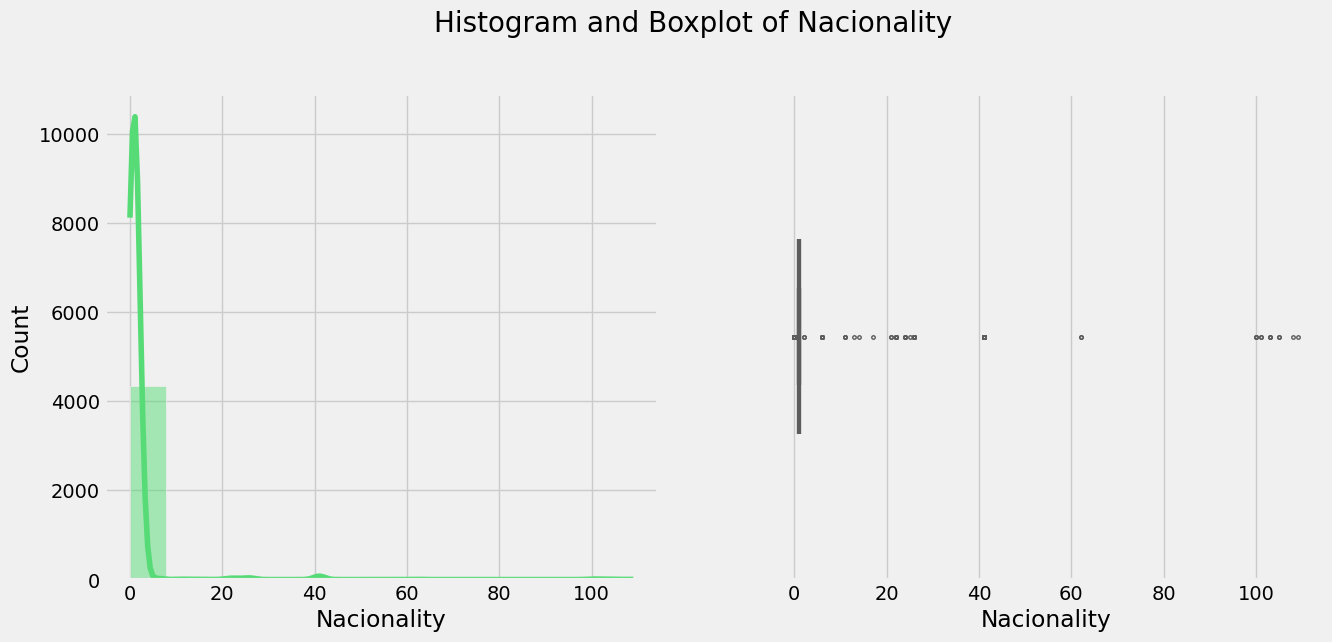

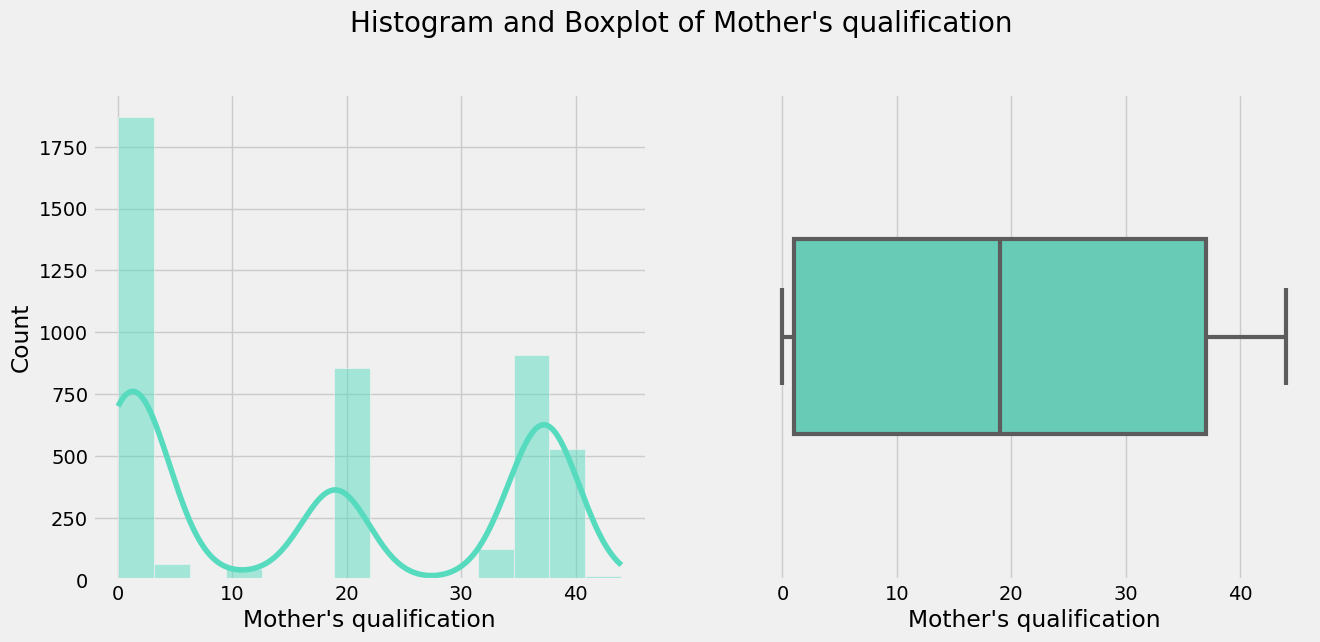

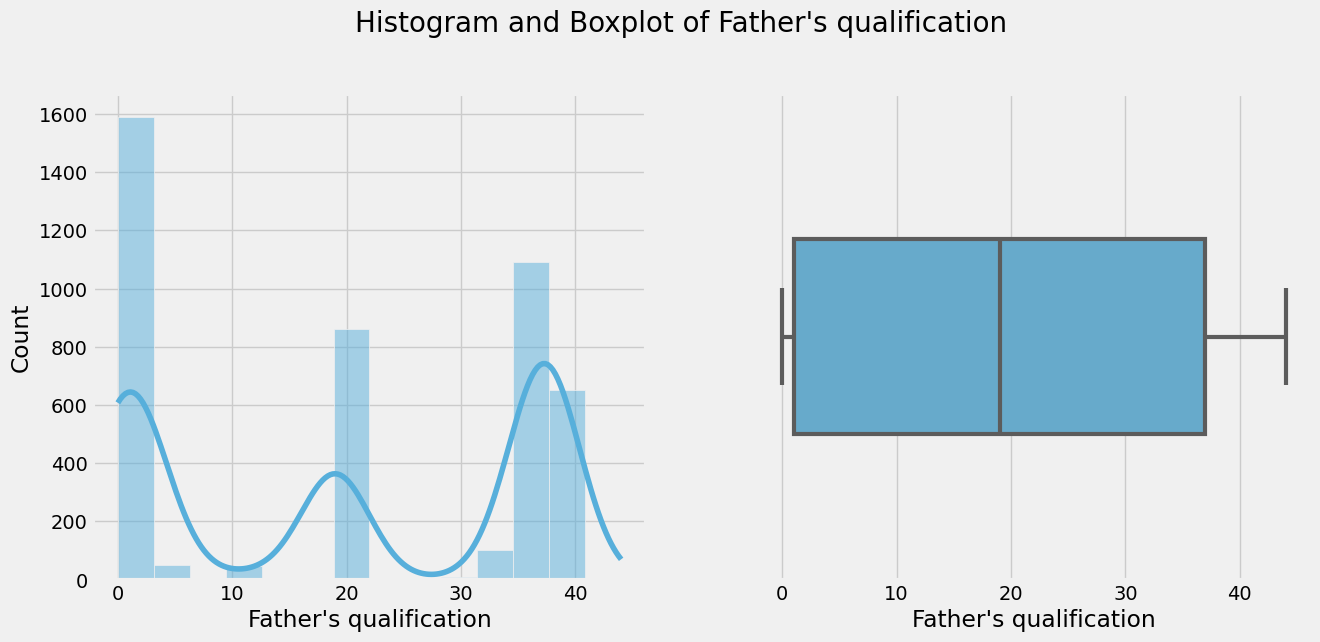

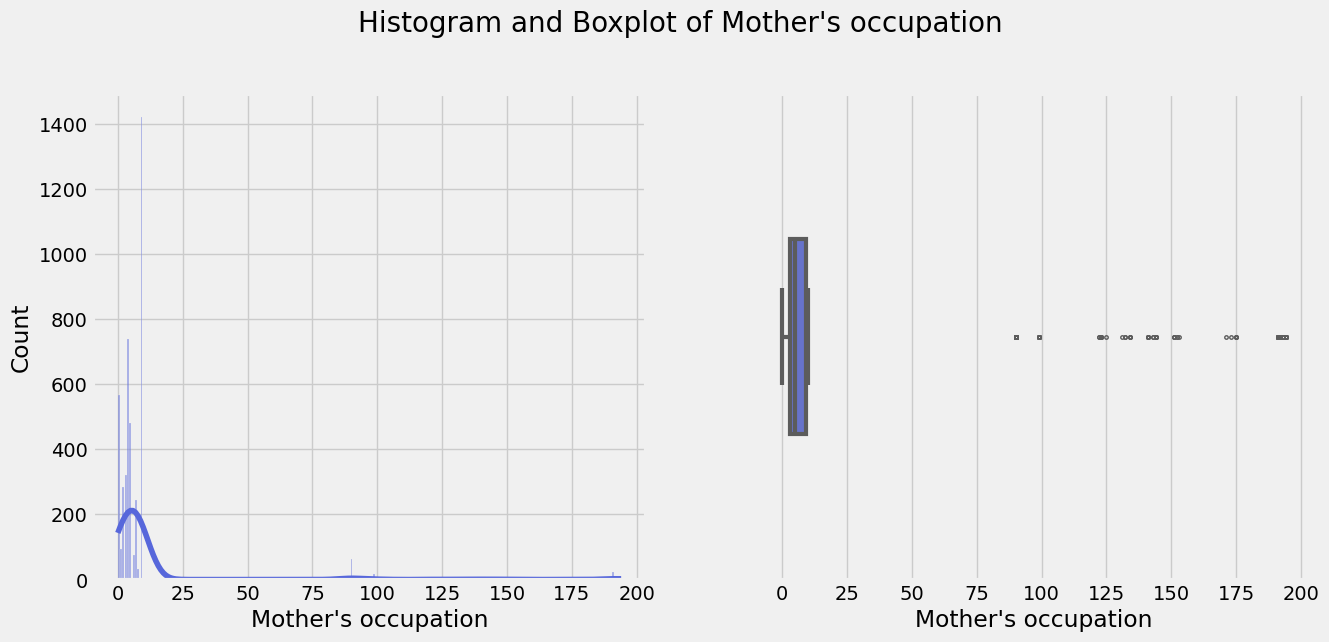

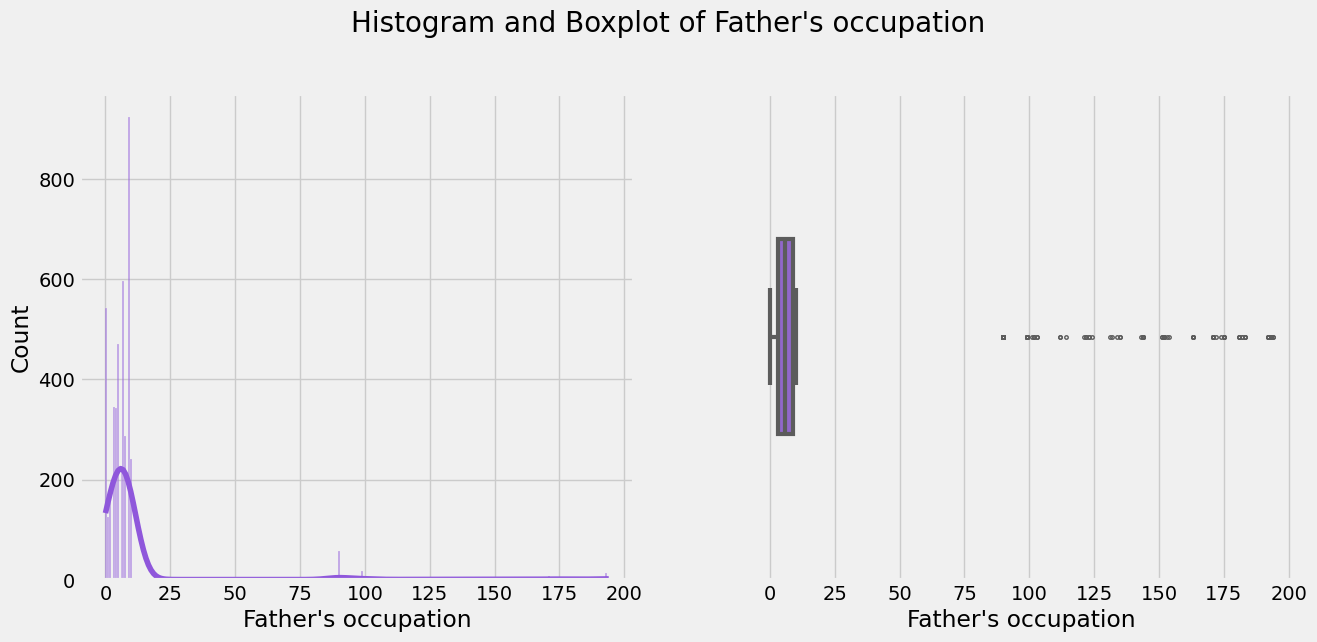

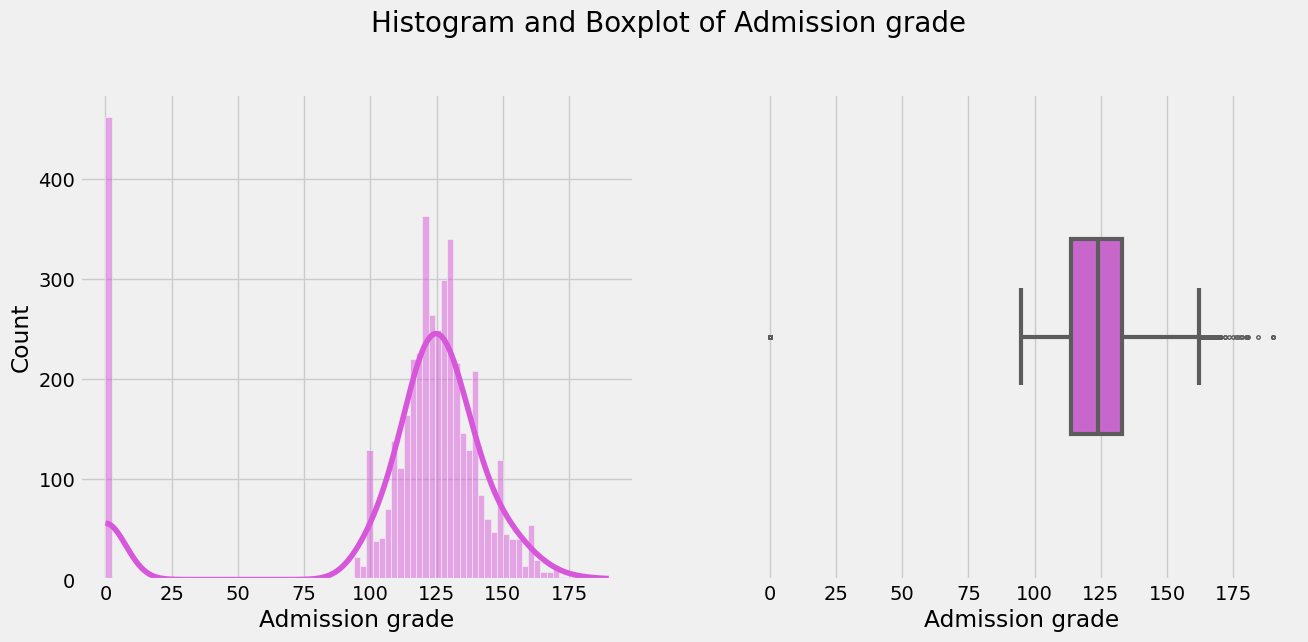

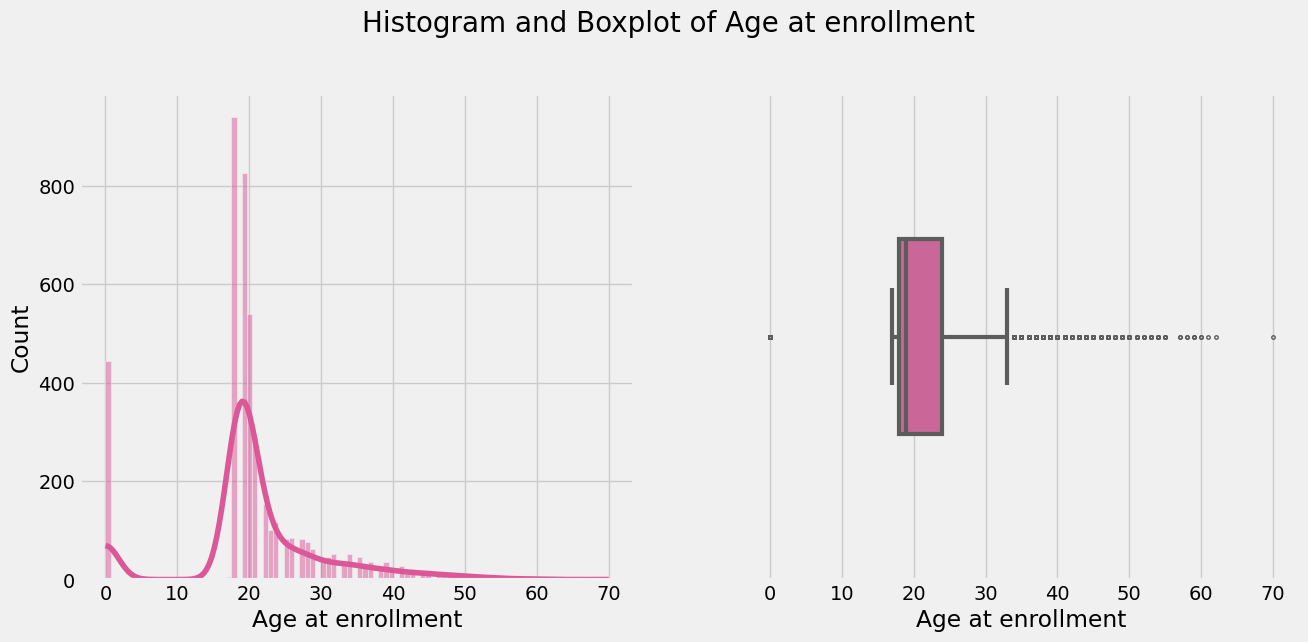

----------------------------------------------------------------------------------------------------
Countplot(s):



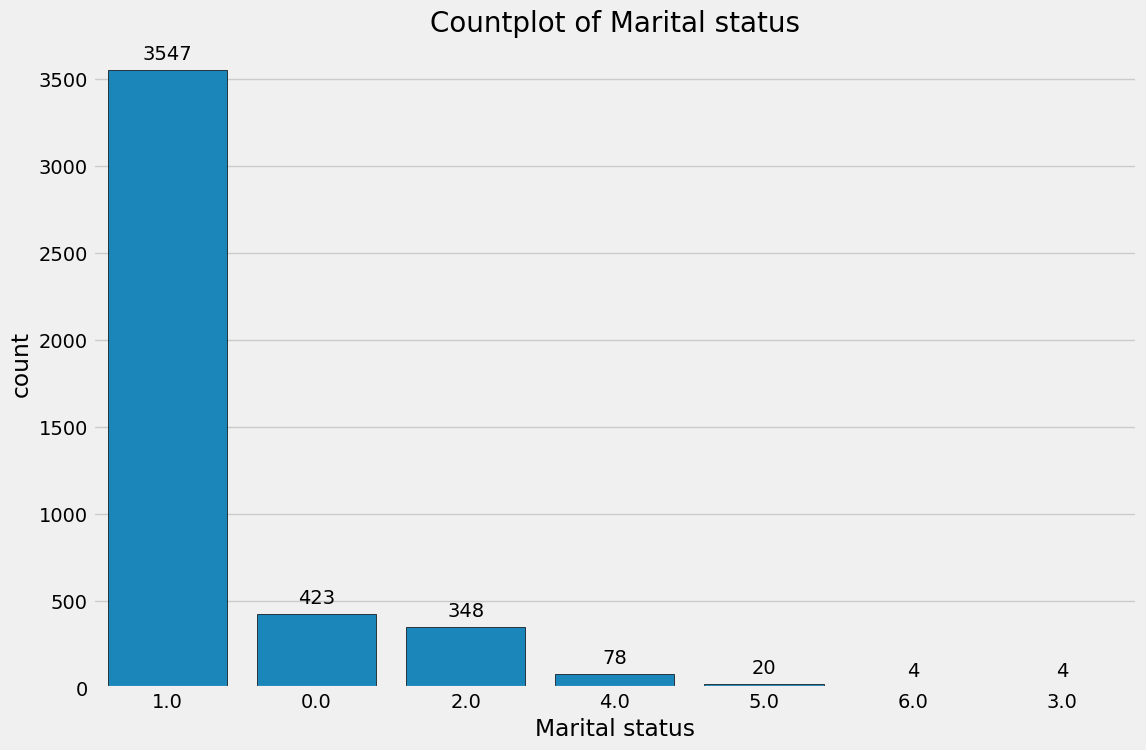

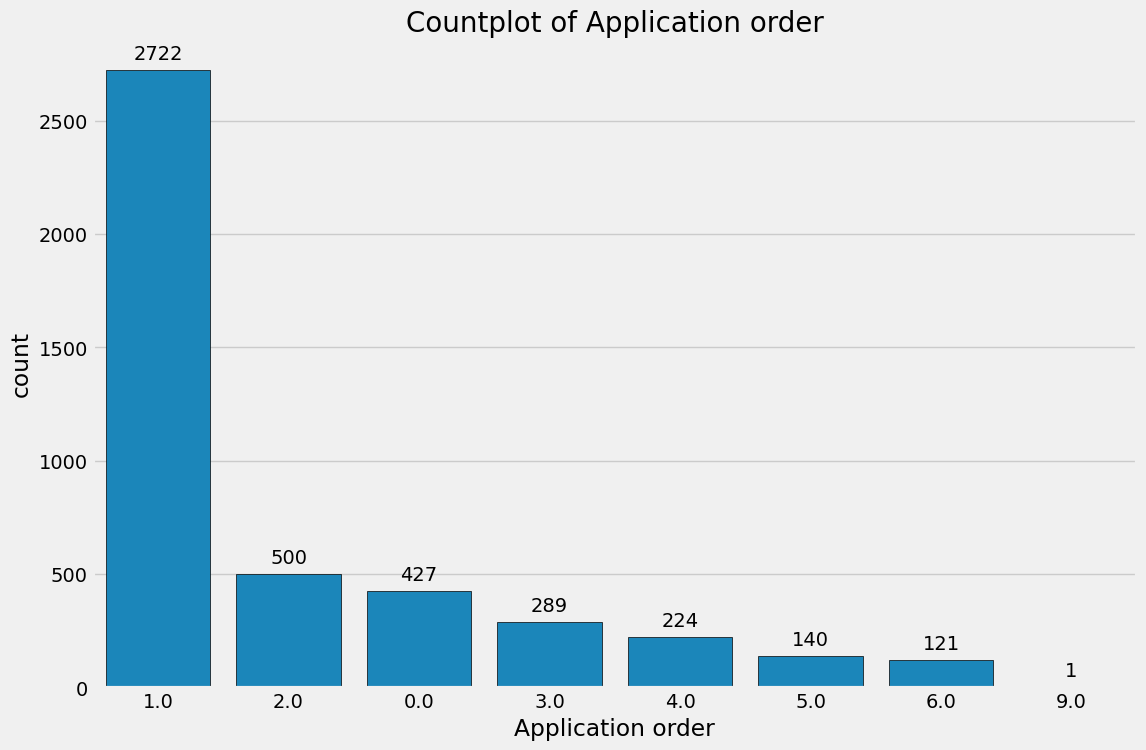

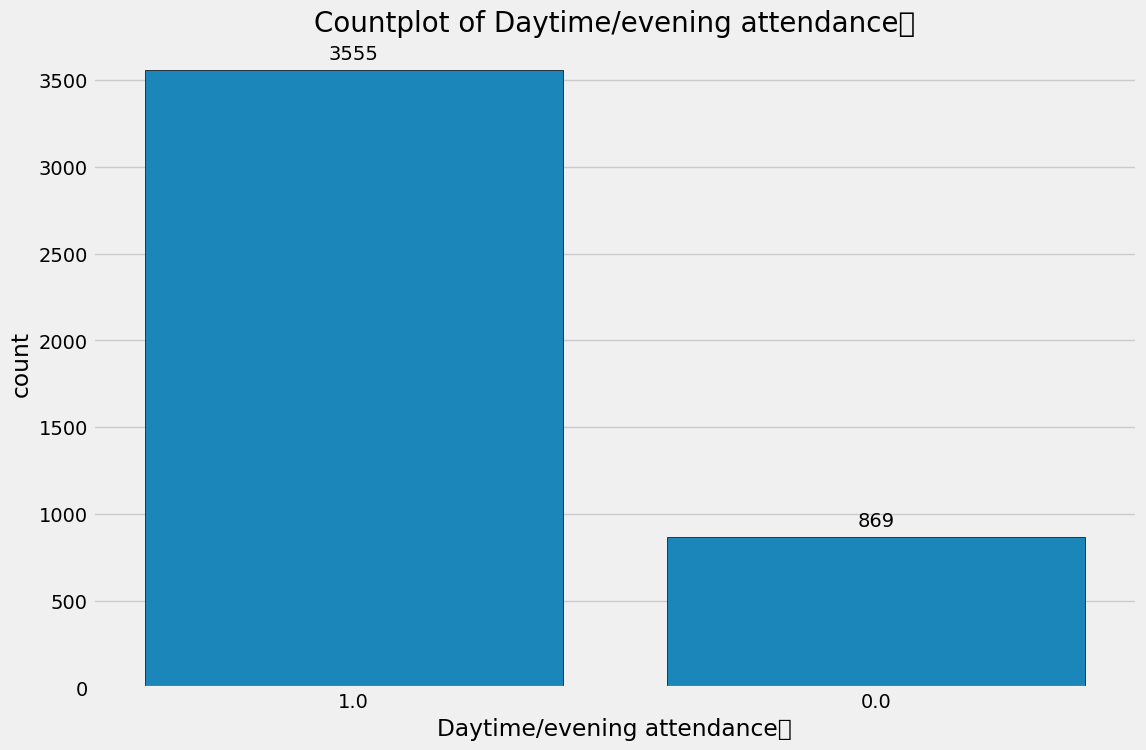

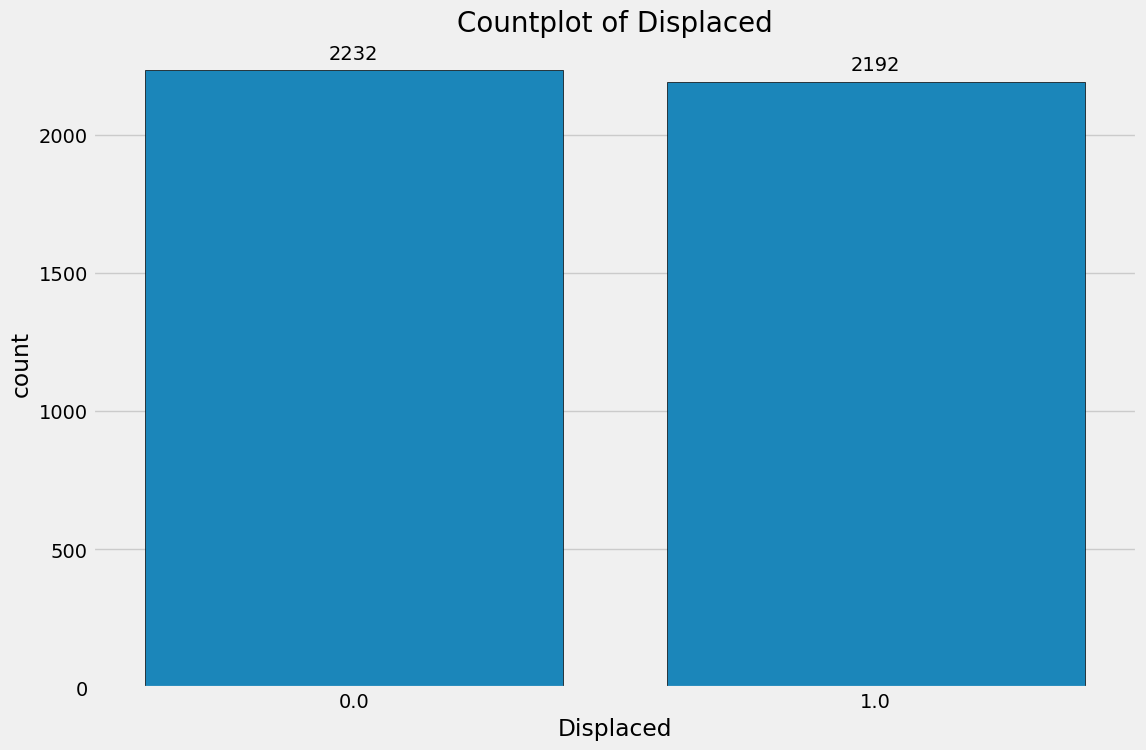

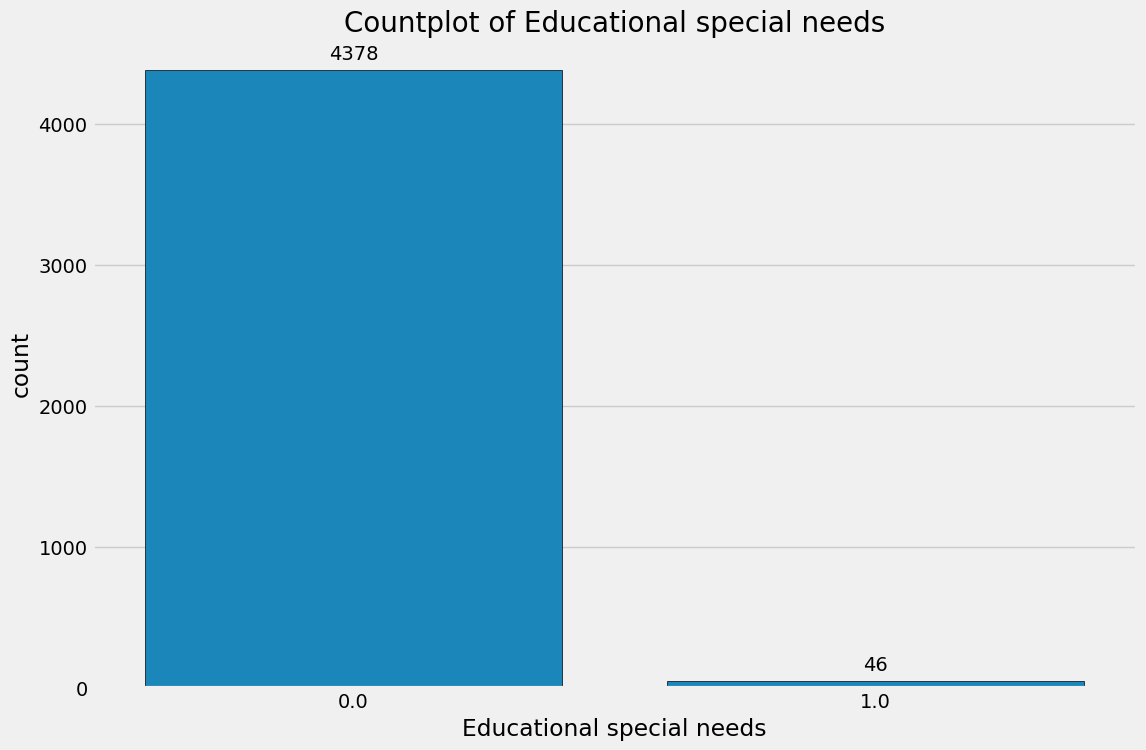

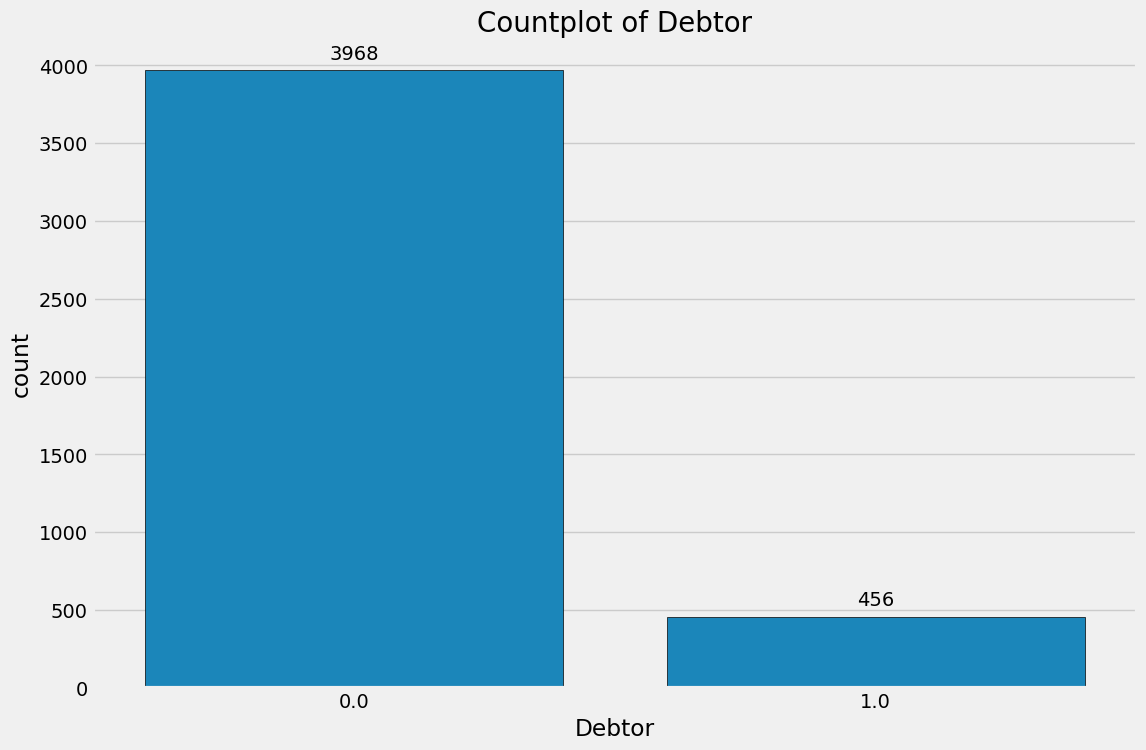

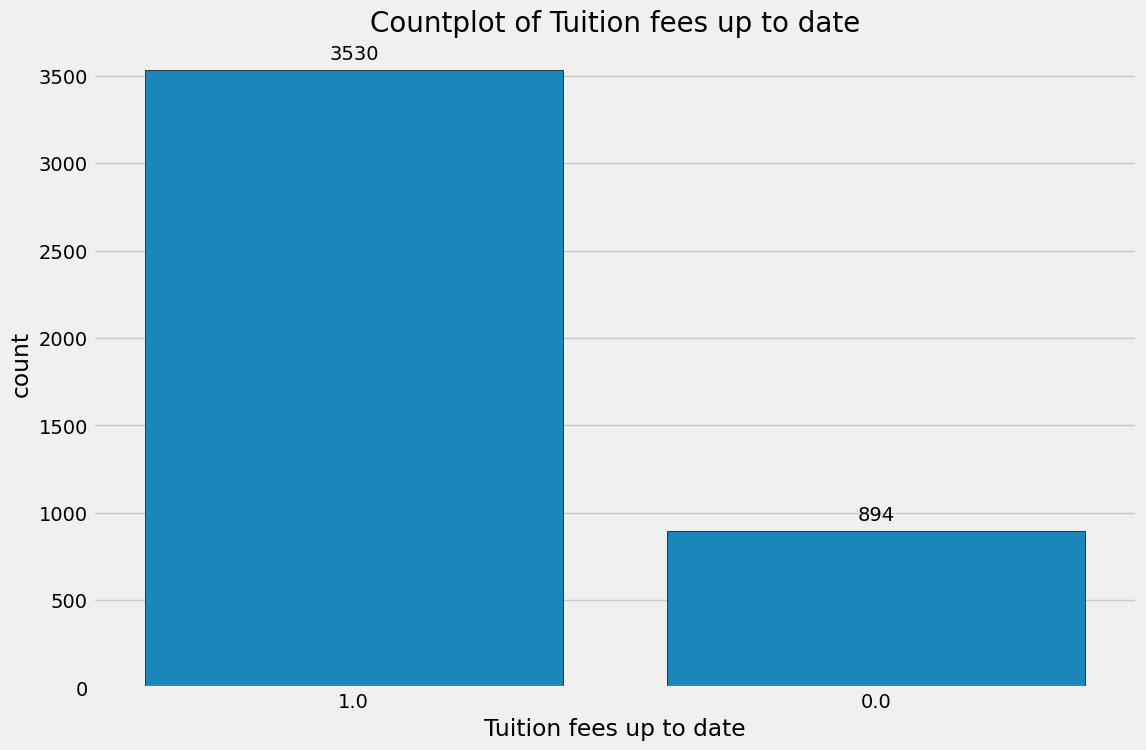

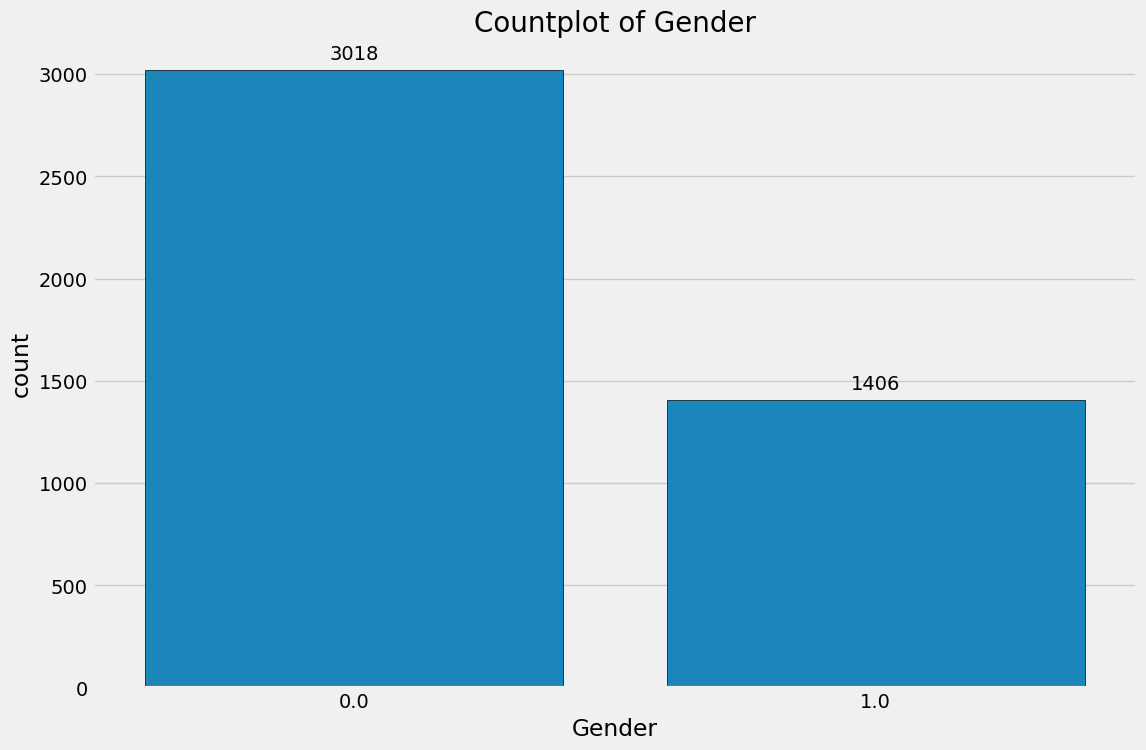

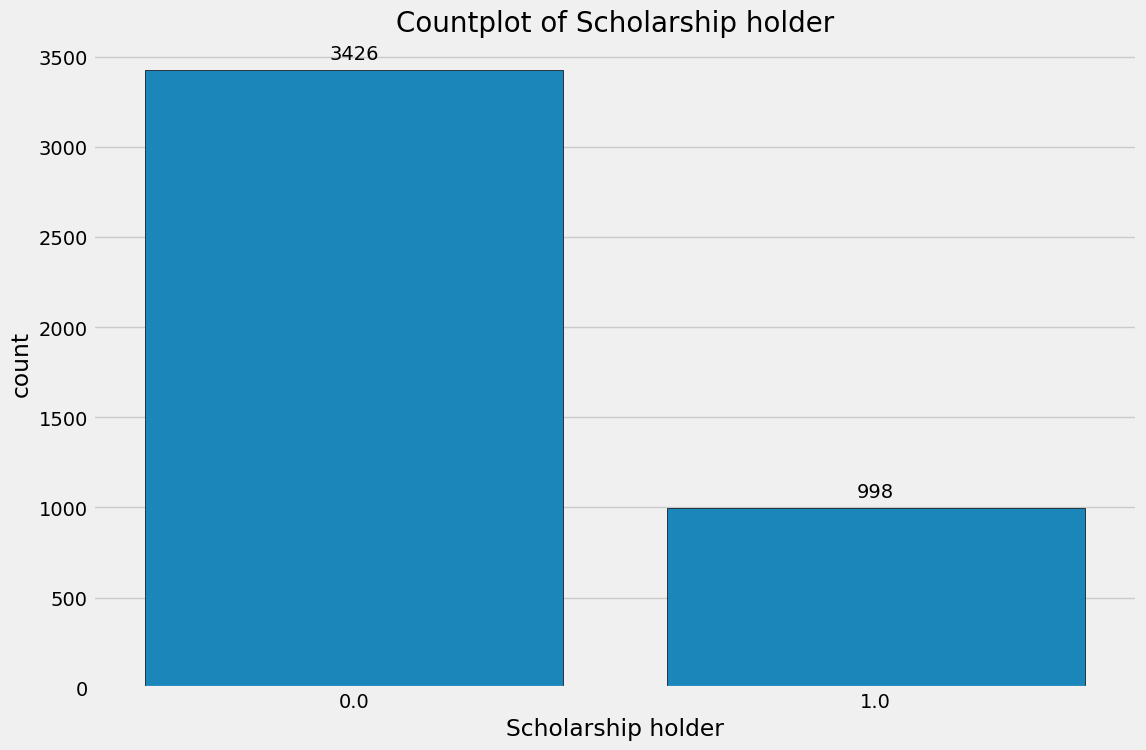

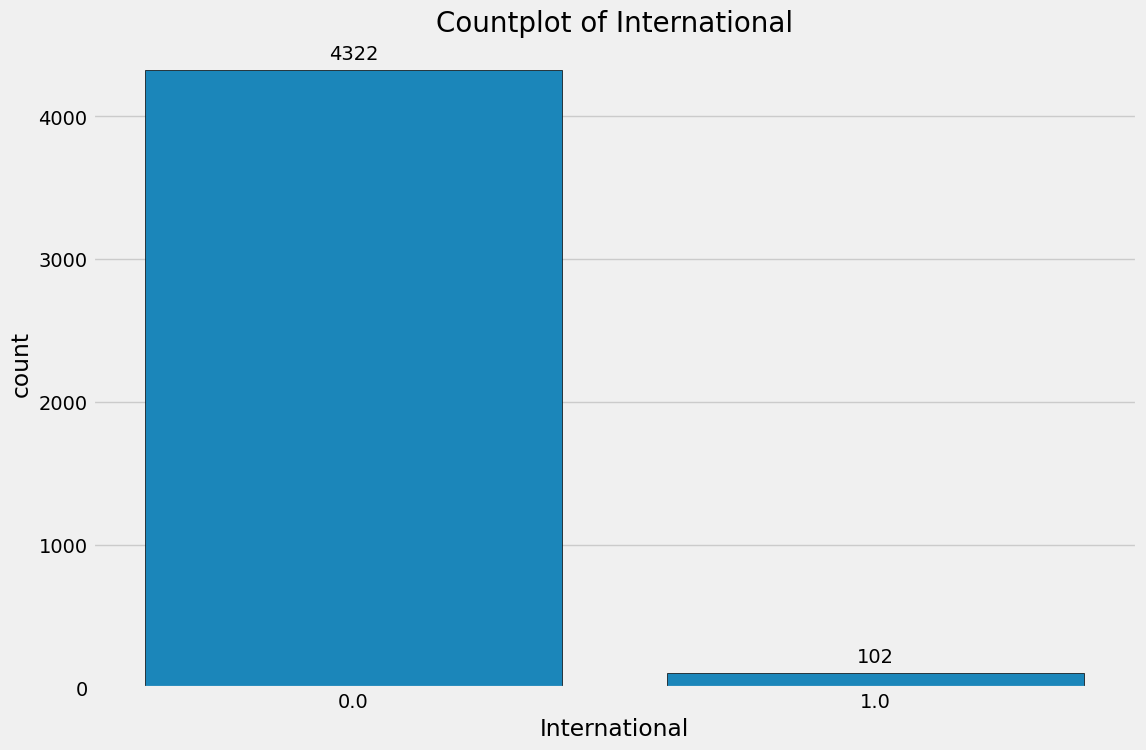

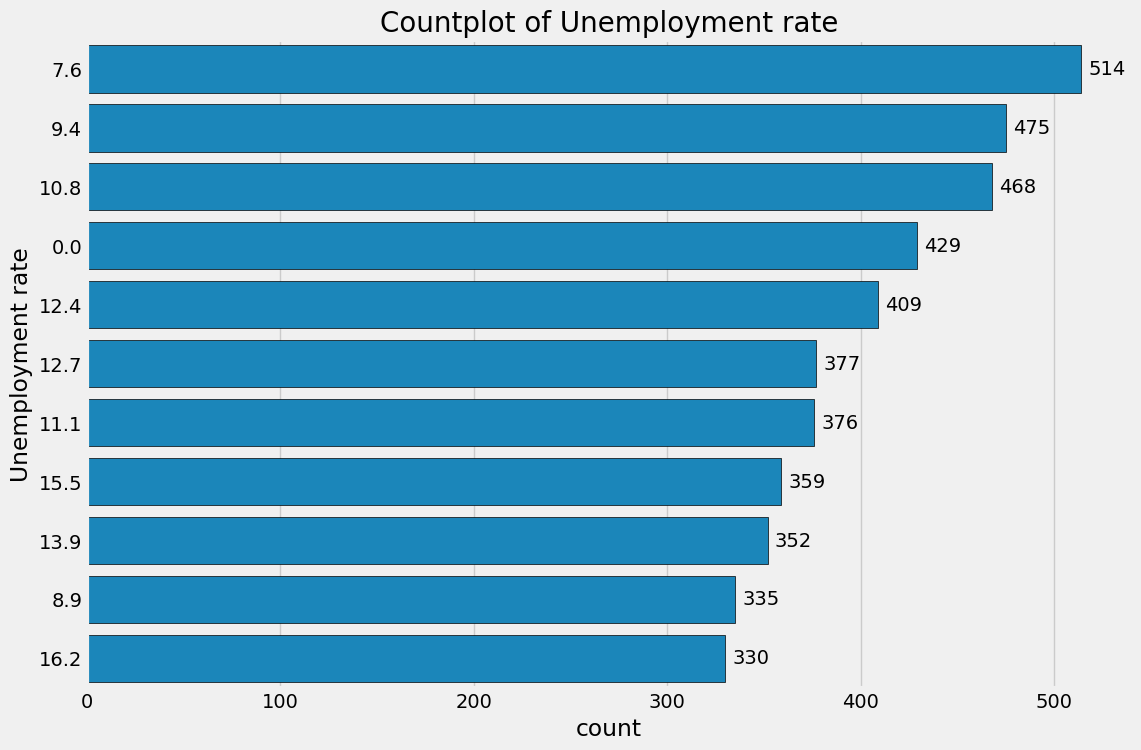

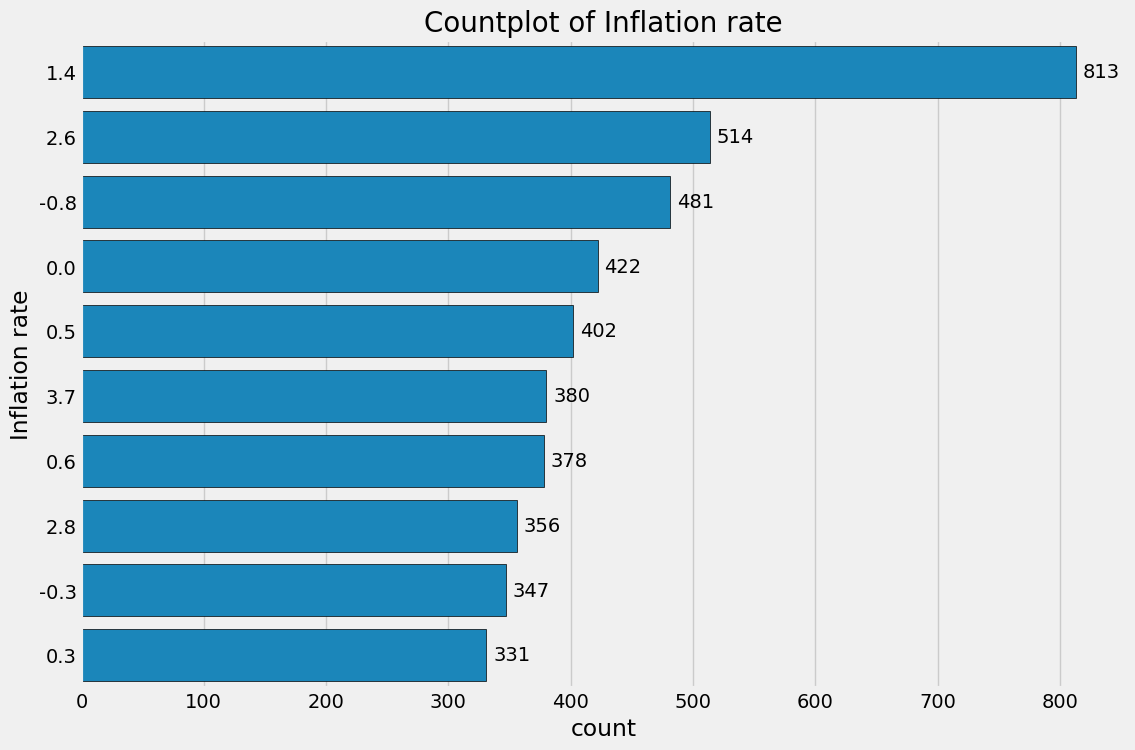

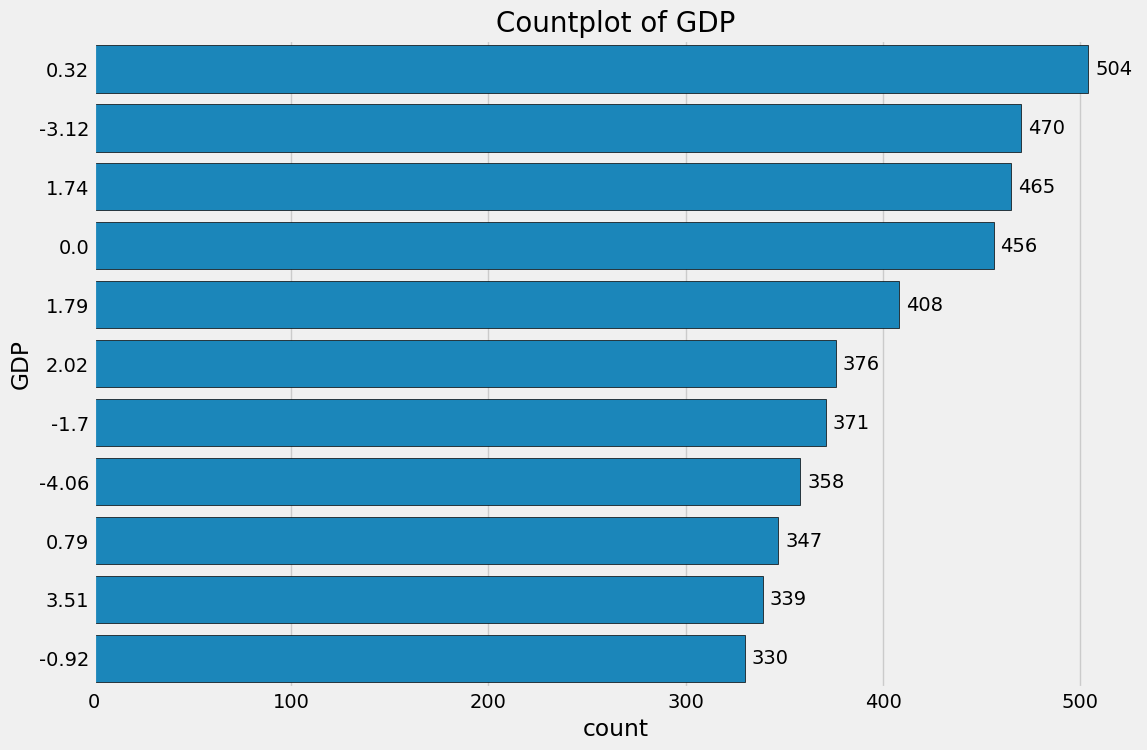

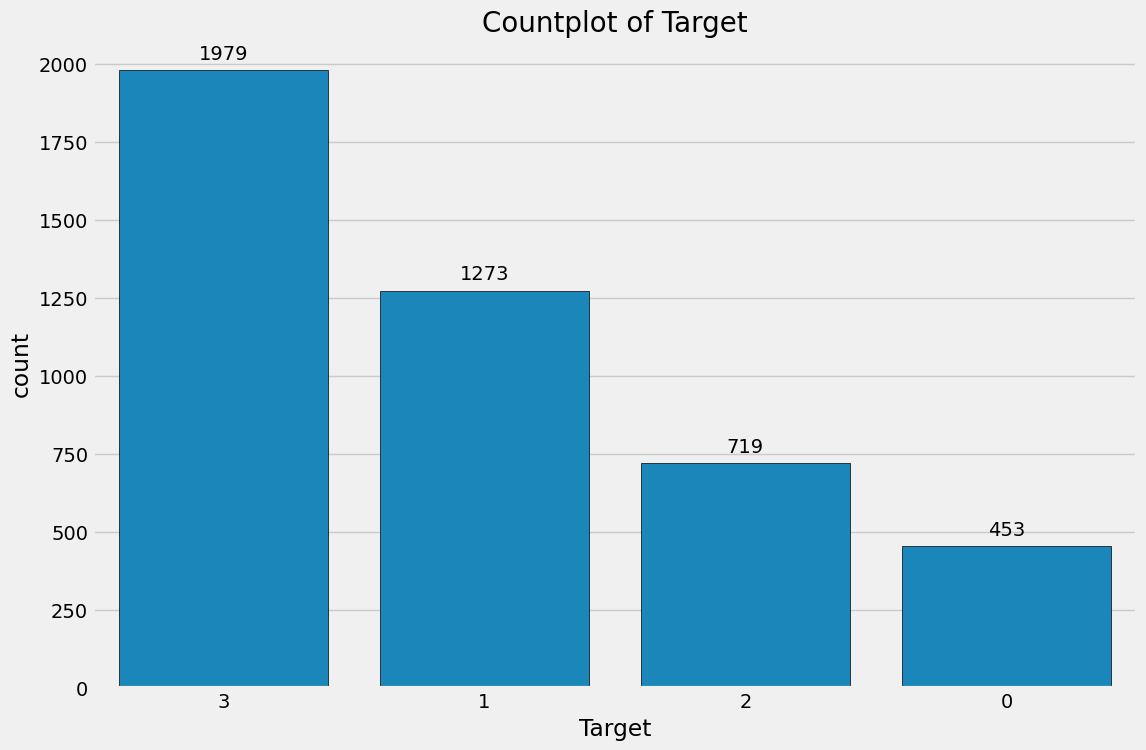

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

In [156]:
from fasteda import fast_eda
fast_eda(df)

In [157]:
X = df
Y = df["Target"]
X.drop("Target", axis=1, inplace=True)

print("X shape:", X.shape)
print("Y shape:", Y.shape)


X shape: (4424, 26)
Y shape: (4424,)


In [159]:
X

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Unemployment rate,Inflation rate,GDP,Unnamed: 25,Unnamed: 26
0,1.0,17.0,5.0,171.0,1.0,1.0,122.0,1.0,19.0,12.0,5.0,9.0,127.3,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,10.8,1.4,1.74,0.0,0.0
1,1.0,15.0,1.0,9254.0,1.0,1.0,160.0,1.0,1.0,3.0,3.0,3.0,142.5,1.0,0.0,0.0,0.0,1.0,0.0,19.0,0.0,13.9,-0.3,0.79,0.0,0.0
2,1.0,0.0,5.0,9070.0,1.0,1.0,122.0,0.0,37.0,37.0,0.0,9.0,124.8,1.0,0.0,0.0,0.0,1.0,0.0,19.0,0.0,10.8,1.4,1.74,0.0,0.0
3,1.0,17.0,2.0,9773.0,1.0,1.0,122.0,1.0,38.0,37.0,5.0,0.0,119.6,1.0,0.0,0.0,1.0,0.0,0.0,20.0,0.0,9.4,-0.8,-3.12,0.0,0.0
4,2.0,39.0,1.0,8014.0,0.0,1.0,100.0,1.0,37.0,0.0,9.0,9.0,141.5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,13.9,-0.3,0.79,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,0.0,1.0,6.0,9773.0,1.0,1.0,125.0,1.0,1.0,1.0,5.0,4.0,122.2,0.0,0.0,0.0,1.0,1.0,0.0,19.0,0.0,0.0,2.8,-4.06,0.0,0.0
4420,1.0,1.0,2.0,9773.0,1.0,1.0,120.0,105.0,1.0,1.0,0.0,9.0,119.0,1.0,0.0,1.0,0.0,0.0,0.0,18.0,1.0,11.1,0.6,2.02,0.0,0.0
4421,1.0,1.0,1.0,9500.0,1.0,1.0,154.0,1.0,37.0,37.0,9.0,9.0,149.5,0.0,0.0,0.0,1.0,0.0,1.0,30.0,0.0,13.9,-0.3,0.79,0.0,0.0
4422,1.0,1.0,1.0,9147.0,1.0,1.0,180.0,1.0,37.0,37.0,7.0,4.0,153.8,1.0,0.0,0.0,1.0,0.0,1.0,20.0,0.0,9.4,-0.8,-3.12,0.0,0.0


In [160]:
Y


,Target
0,1
1,3
2,1
3,3
4,3
...,...
4419,0
4420,1
4421,1
4422,3


In [161]:
st= StandardScaler() #feature scaling (0-1)
X=st.fit_transform(X)
X


array([[-0.09226596,  0.02660664,  2.55184982, ...,  0.80055251,
         0.        ,  0.        ],
       [-0.09226596, -0.0879508 , -0.4190406 , ...,  0.35945466,
         0.        ,  0.        ],
       [-0.09226596, -0.94713156,  2.55184982, ...,  0.80055251,
         0.        ,  0.        ],
       ...,
       [-0.09226596, -0.88985285, -0.4190406 , ...,  0.35945466,
         0.        ,  0.        ],
       [-0.09226596, -0.88985285, -0.4190406 , ..., -1.45601124,
         0.        ,  0.        ],
       [-0.09226596, -0.37434439, -0.4190406 , ..., -0.79668603,
         0.        ,  0.        ]])

DataFrame Head:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Unemployment rate,Inflation rate,GDP,Target,Unnamed: 25,Unnamed: 26
0,1.0,17.0,5.0,171.0,1.0,1.0,122.0,1.0,19.0,12.0,5.0,9.0,127.3,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,10.8,1.4,1.74,1,0.0,0.0
1,1.0,15.0,1.0,9254.0,1.0,1.0,160.0,1.0,1.0,3.0,3.0,3.0,142.5,1.0,0.0,0.0,0.0,1.0,0.0,19.0,0.0,13.9,-0.3,0.79,3,0.0,0.0
2,1.0,0.0,5.0,9070.0,1.0,1.0,122.0,0.0,37.0,37.0,0.0,9.0,124.8,1.0,0.0,0.0,0.0,1.0,0.0,19.0,0.0,10.8,1.4,1.74,1,0.0,0.0


DataFrame Tail:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Unemployment rate,Inflation rate,GDP,Target,Unnamed: 25,Unnamed: 26
4421,1.0,1.0,1.0,9500.0,1.0,1.0,154.0,1.0,37.0,37.0,9.0,9.0,149.5,0.0,0.0,0.0,1.0,0.0,1.0,30.0,0.0,13.9,-0.3,0.79,1,0.0,0.0
4422,1.0,1.0,1.0,9147.0,1.0,1.0,180.0,1.0,37.0,37.0,7.0,4.0,153.8,1.0,0.0,0.0,1.0,0.0,1.0,20.0,0.0,9.4,-0.8,-3.12,3,0.0,0.0
4423,1.0,10.0,1.0,9773.0,1.0,1.0,152.0,22.0,38.0,37.0,5.0,9.0,152.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,1.0,12.7,3.7,-1.70,3,0.0,0.0


----------------------------------------------------------------------------------------------------
Missing values:


,0


----------------------------------------------------------------------------------------------------
Shape of DataFrame:

(4424, 27)

----------------------------------------------------------------------------------------------------
DataFrame Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Marital status                  4424 non-null   float64
 1   Application mode                4424 non-null   float64
 2   Application order               4424 non-null   float64
 3   Course                          4424 non-null   float64
 4   Daytime/evening attendance	     4424 non-null   float64
 5   Previous qualification          4424 non-null   float64
 6   Previous qualification (grade)  4424 non-null   float64
 7   Nacionality                     4424 non-null   float64
 8   Mother's qualification    

,count,mean,median,std,min,25%,50%,75%,max,skewness,kurtosis
Marital status,4424,1.06,1,0.654,0,1,1,1,6,2.826199,14.146227
Application mode,4424,16.535,16,17.46,0,1,16,39,57,0.572718,-1.301718
Application order,4424,1.564,1,1.347,0,1,1,2,9,1.728254,2.597436
Course,4424,7925.722,9238,3344.976,0,9070,9238,9500,9991,-1.894479,1.683862
Daytime/evening attendance,4424,0.804,1,0.397,0,1,1,1,1,-1.528186,0.335354
Previous qualification,4424,4.082,1,9.717,0,1,1,1,43,3.092749,8.177480
Previous qualification (grade),4424,118.533,131,42.833,0,120,131,140,190,-2.136931,3.369119
Nacionality,4424,1.673,1,6.7,0,1,1,1,109,11.477273,152.883028
Mother's qualification,4424,17.659,19,15.917,0,1,19,37,44,0.182764,-1.688001
Father's qualification,4424,19.945,19,16.05,0,1,19,37,44,-0.074895,-1.719435


----------------------------------------------------------------------------------------------------
DataFrame Correlation:



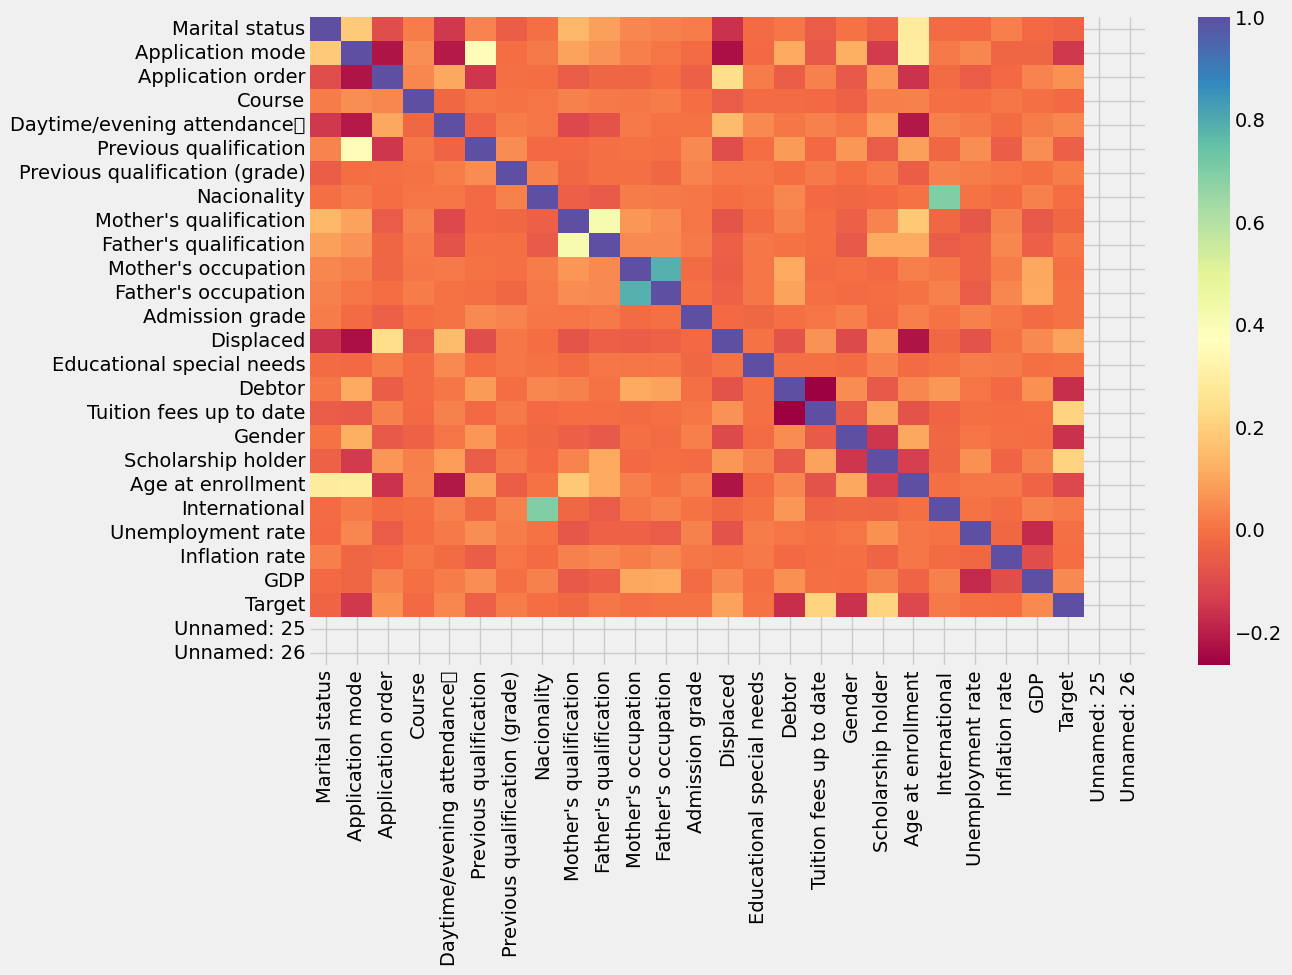

----------------------------------------------------------------------------------------------------
Histogram(s) & Boxplot(s):



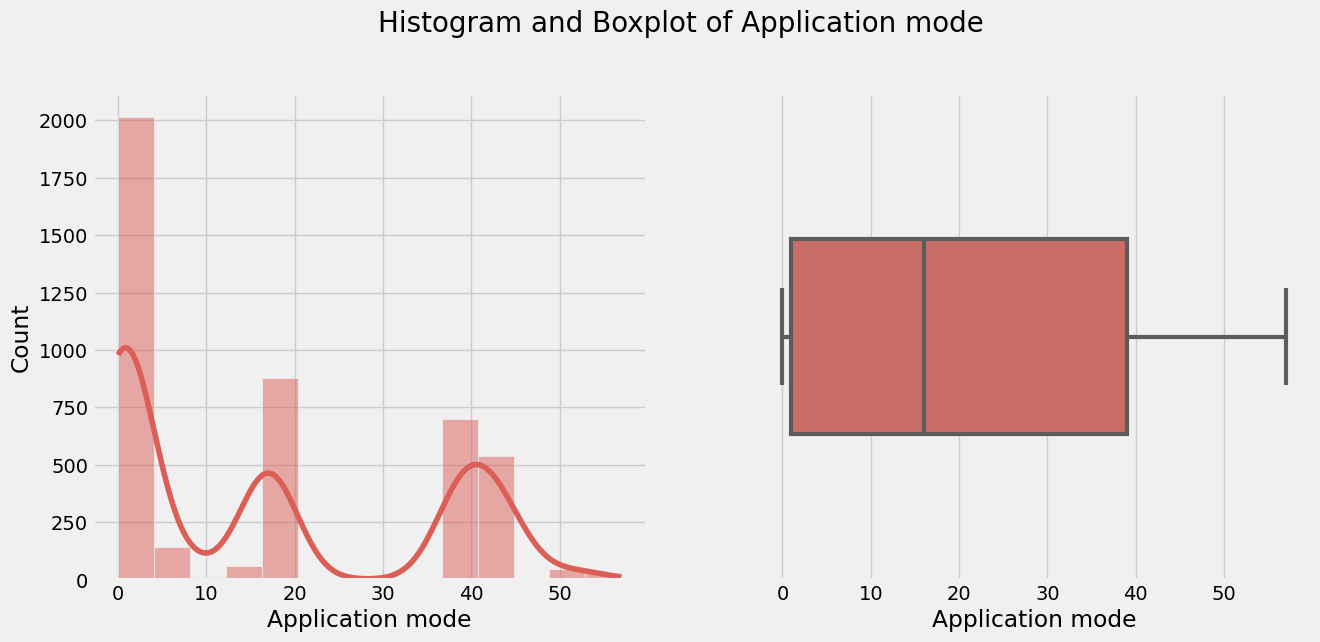

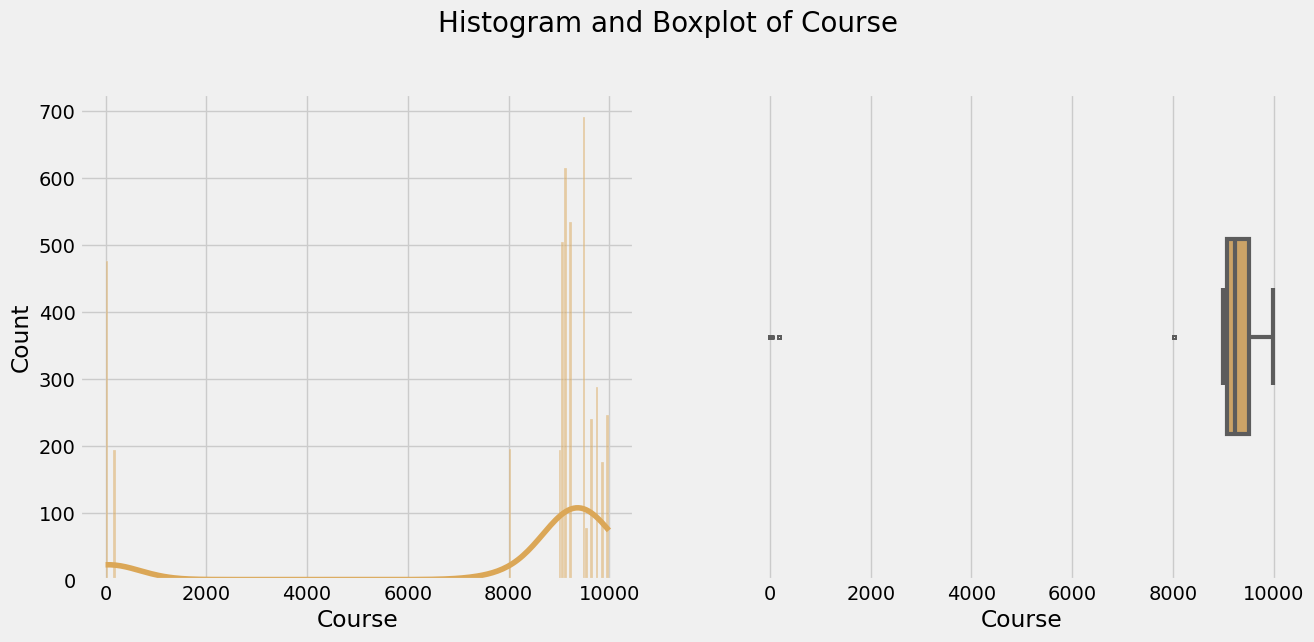

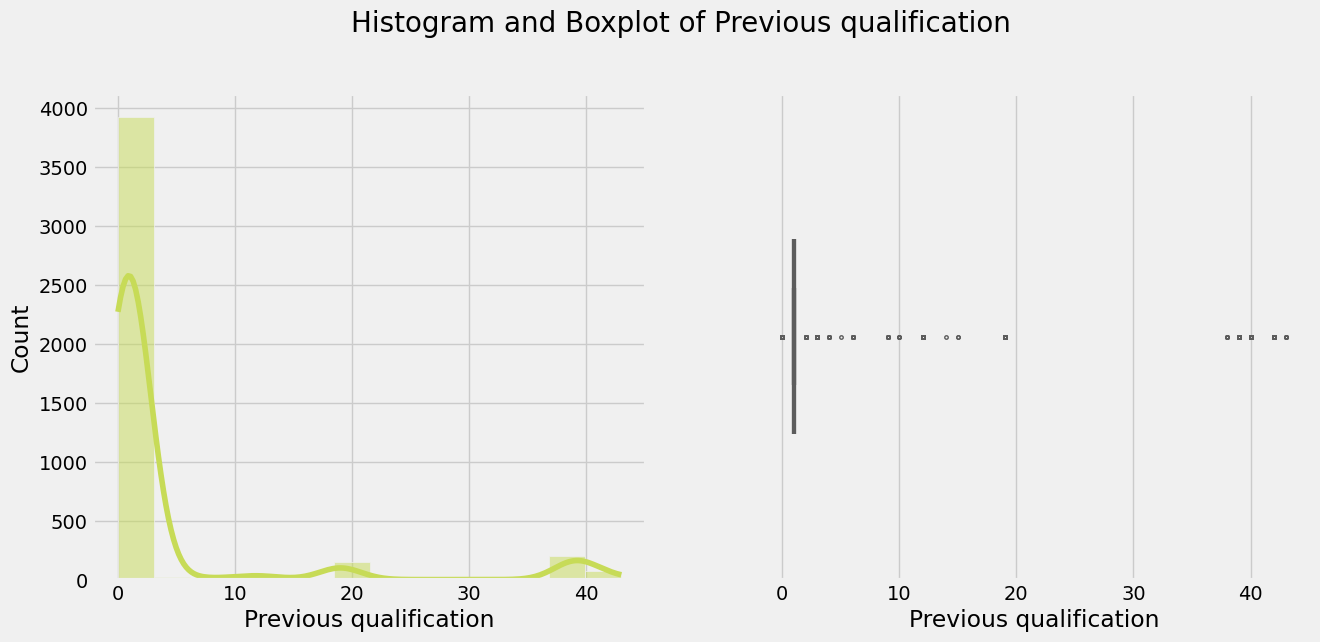

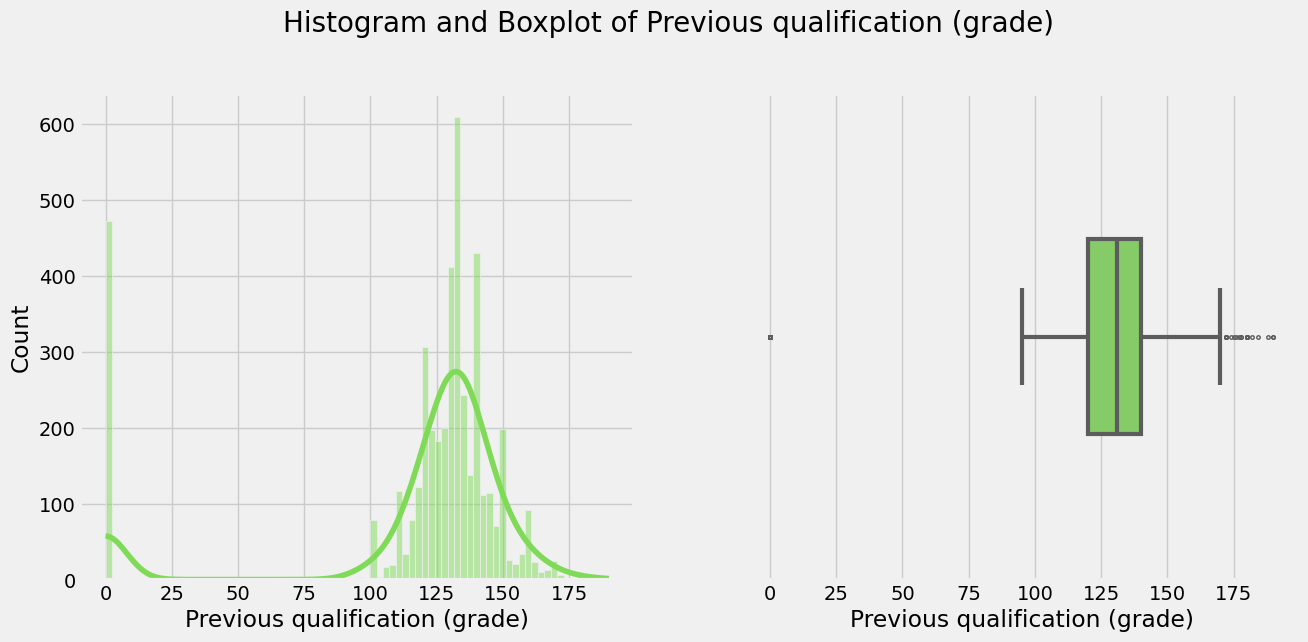

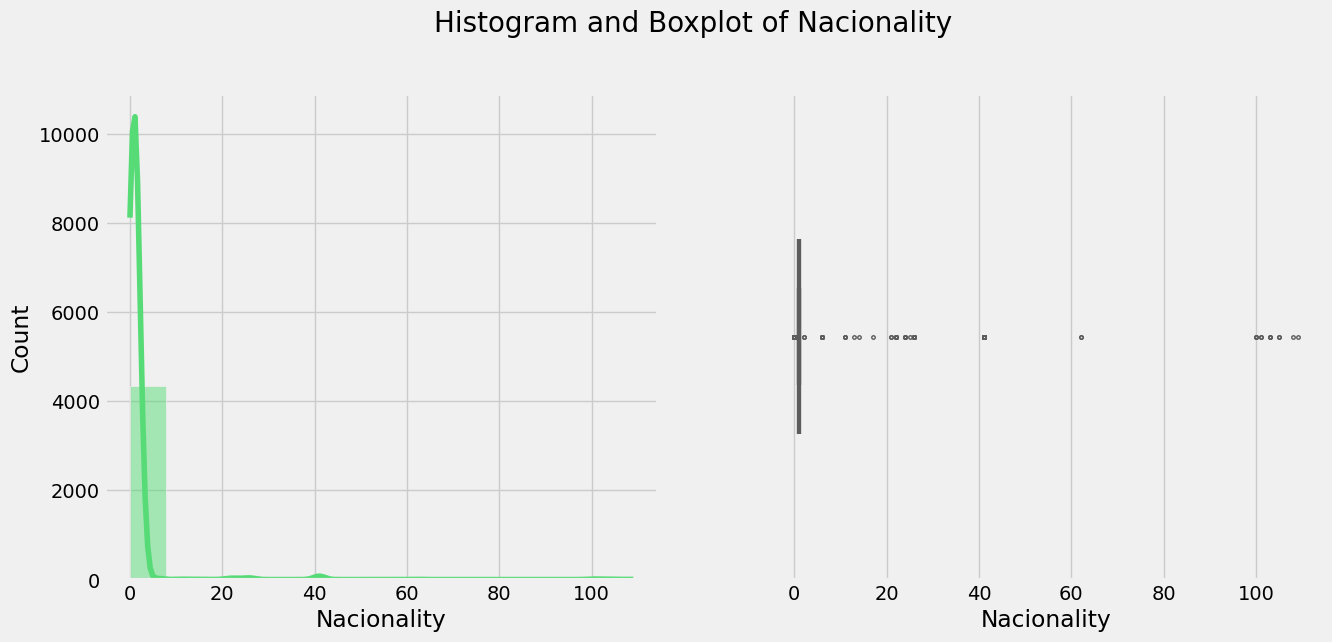

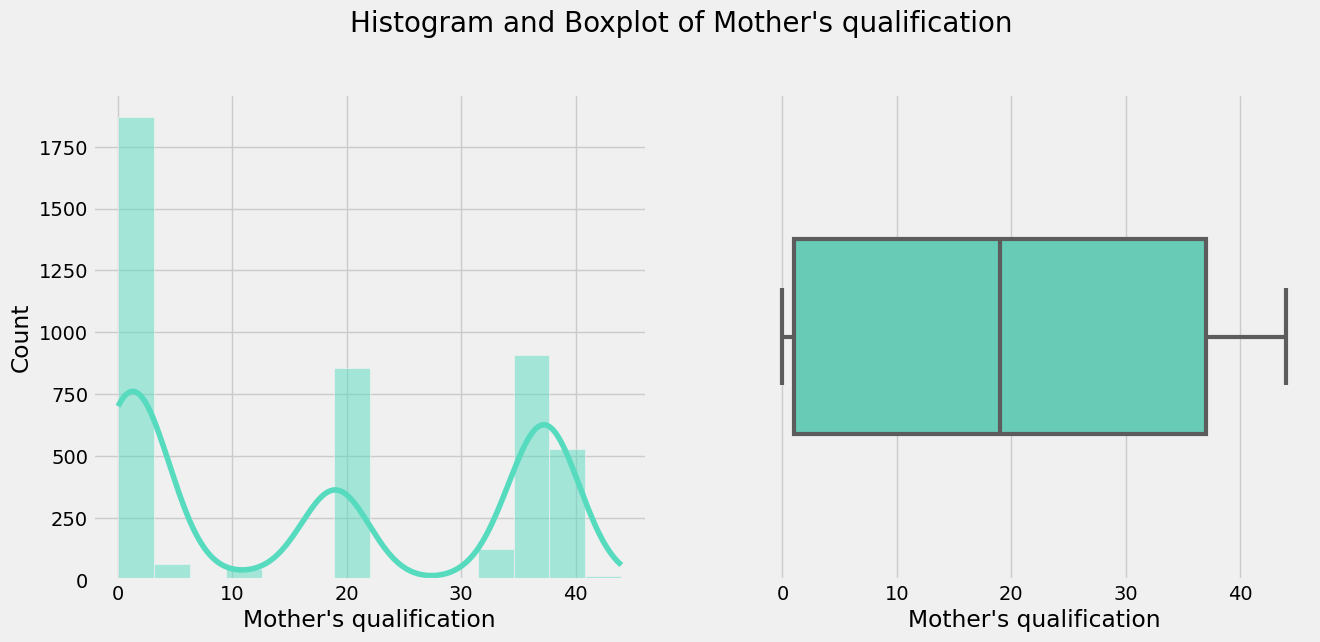

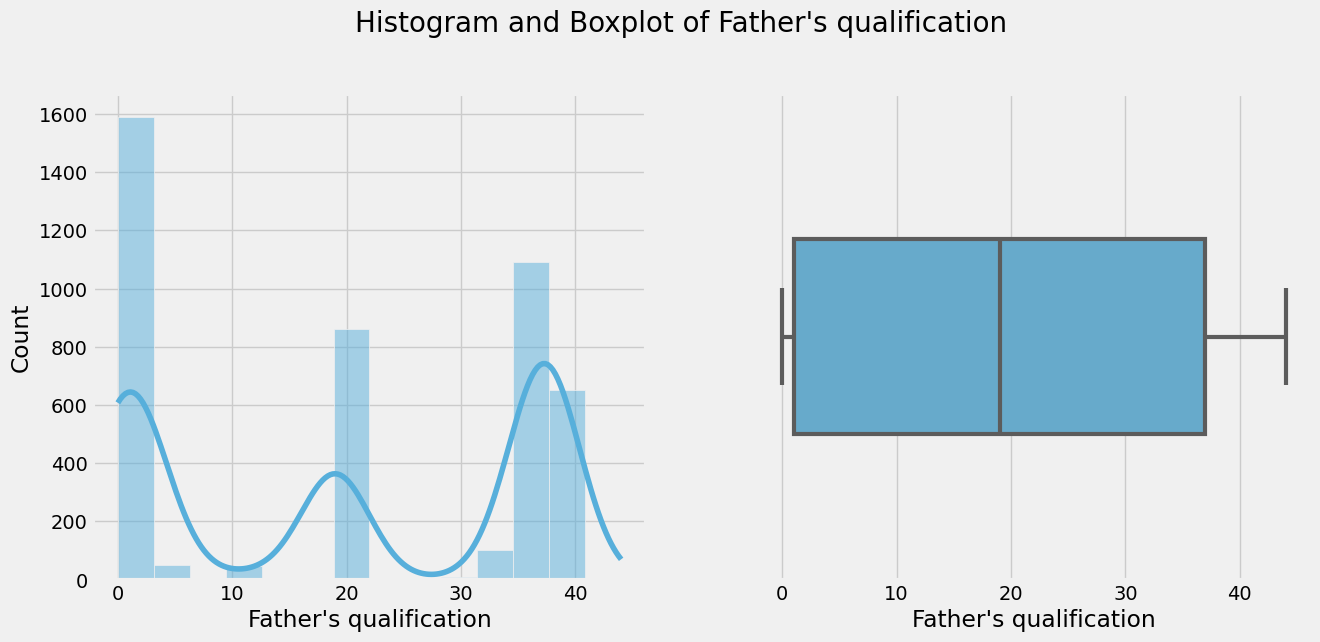

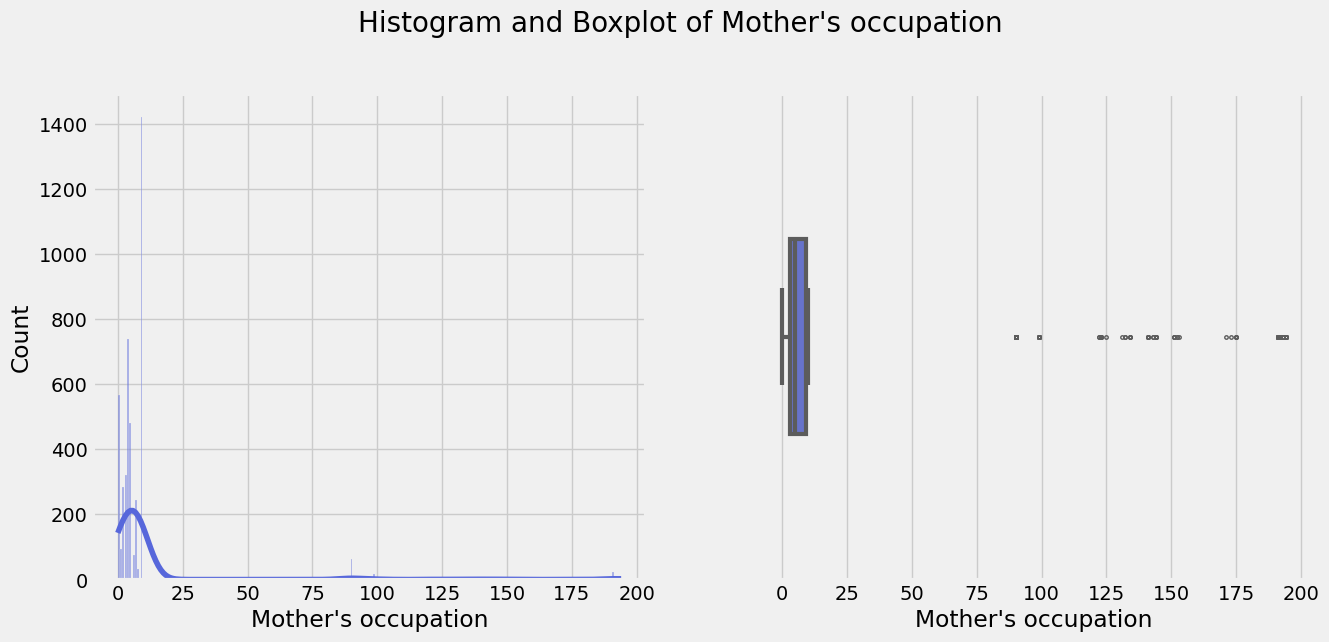

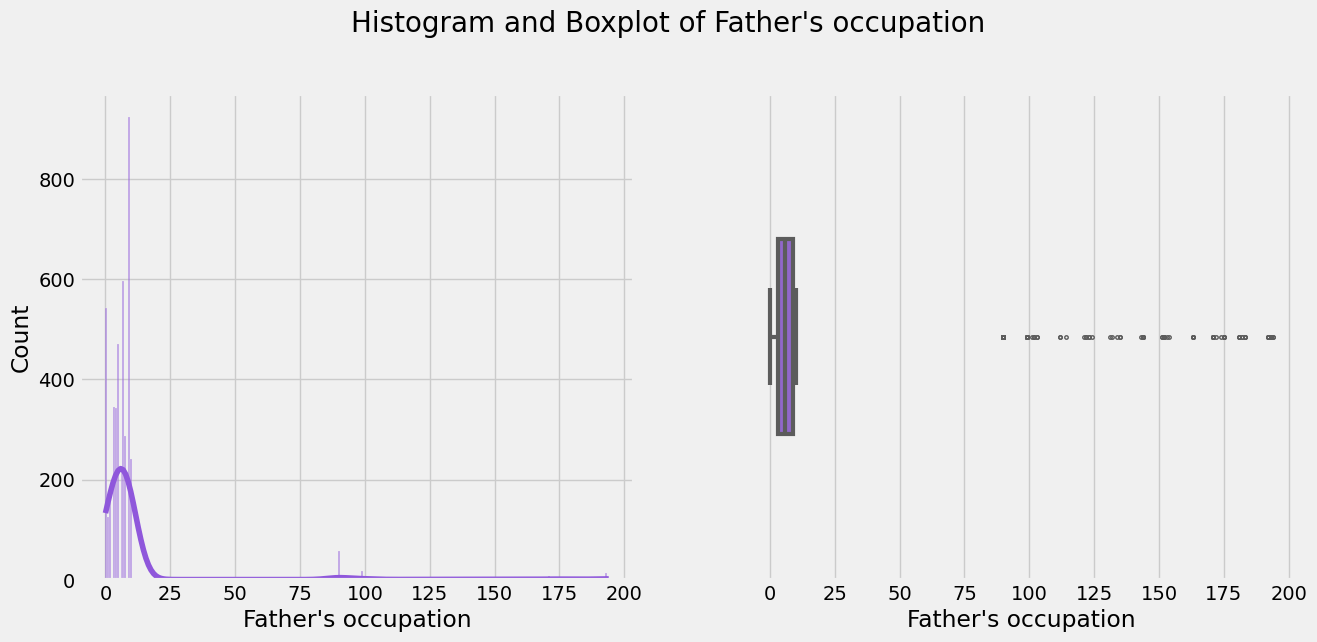

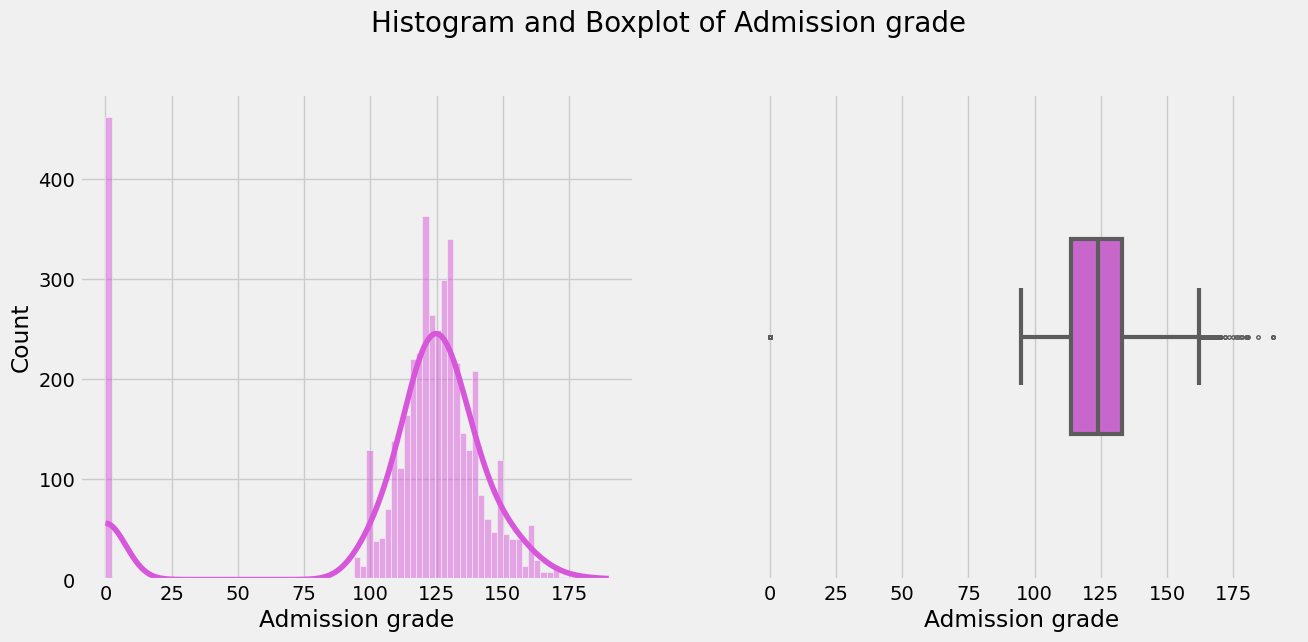

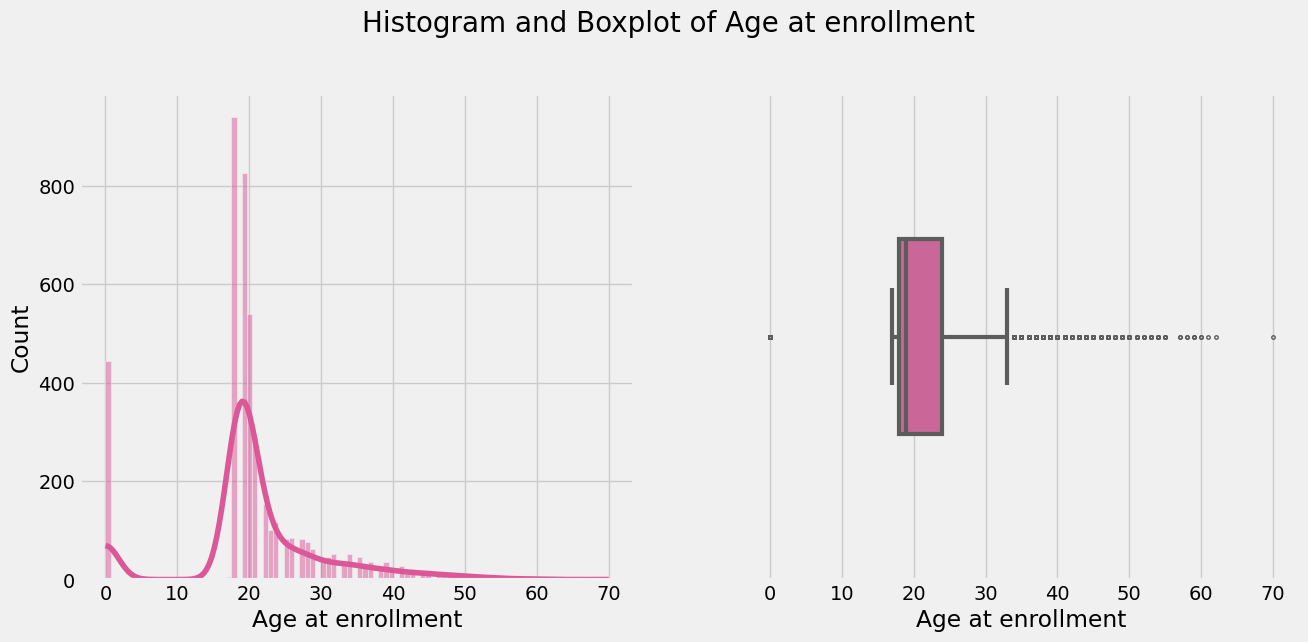

----------------------------------------------------------------------------------------------------
Countplot(s):



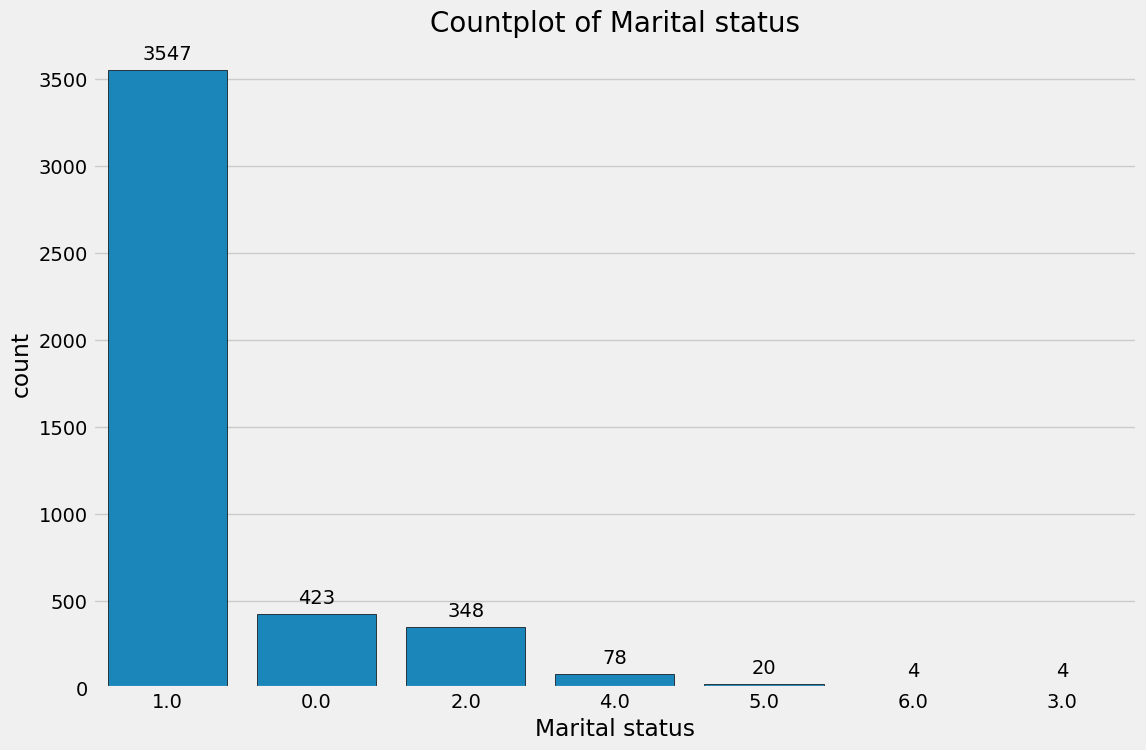

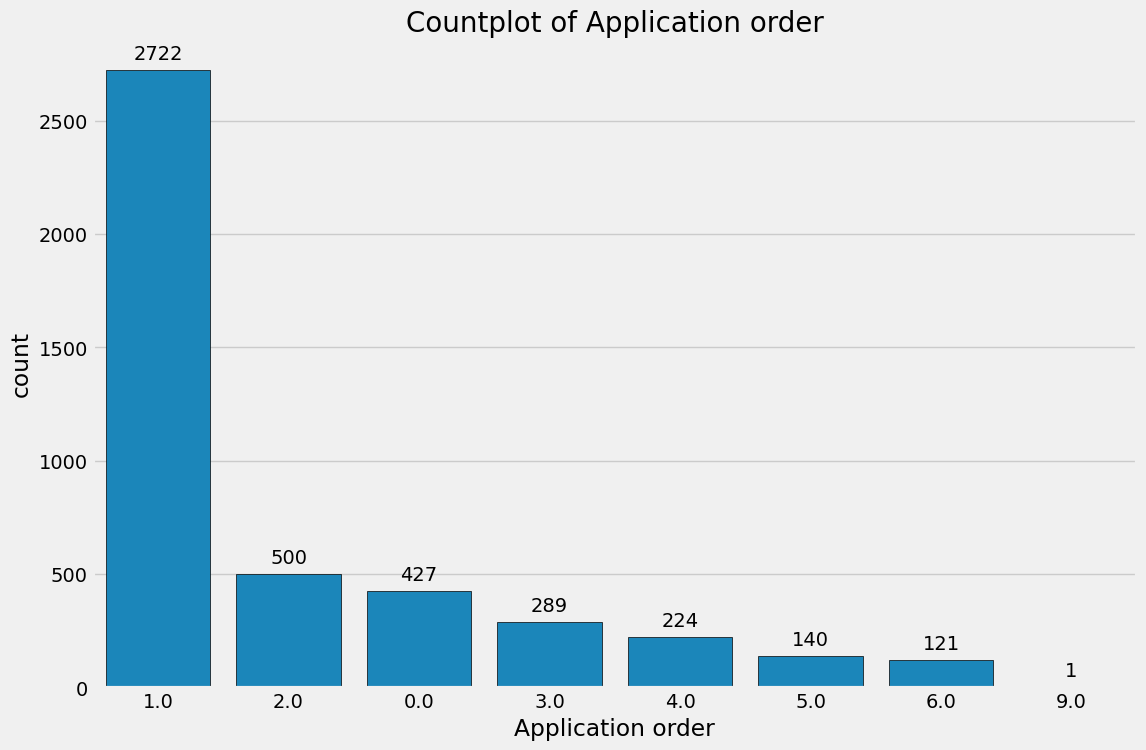

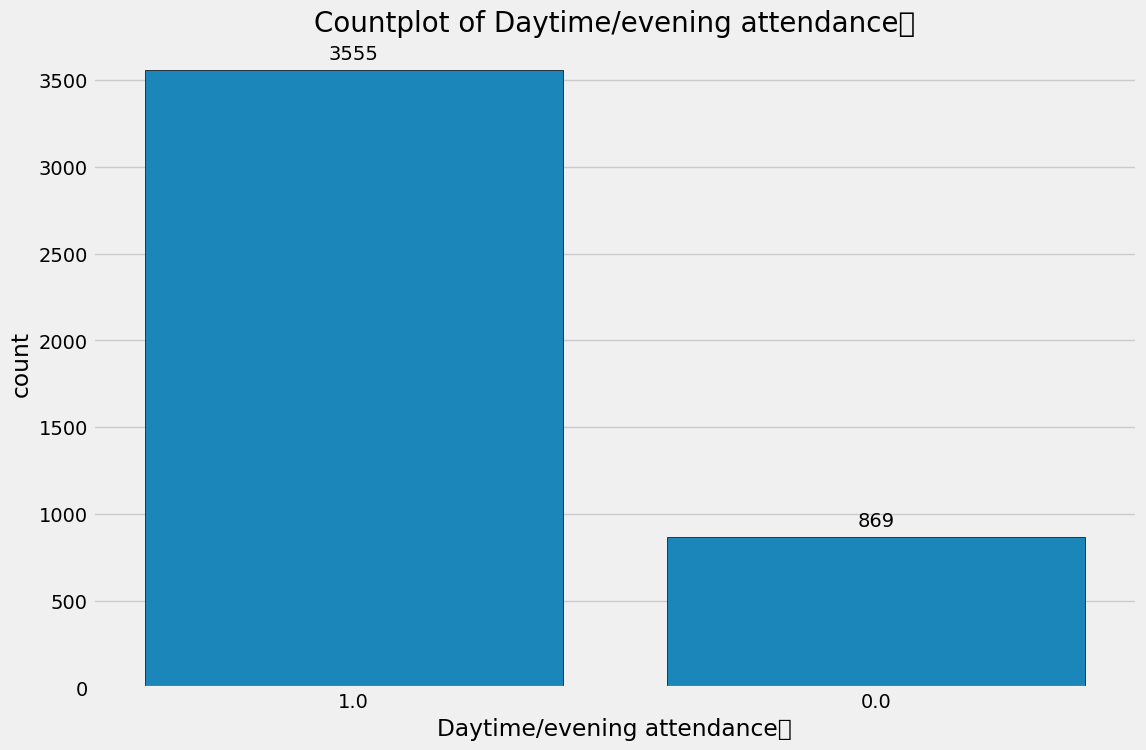

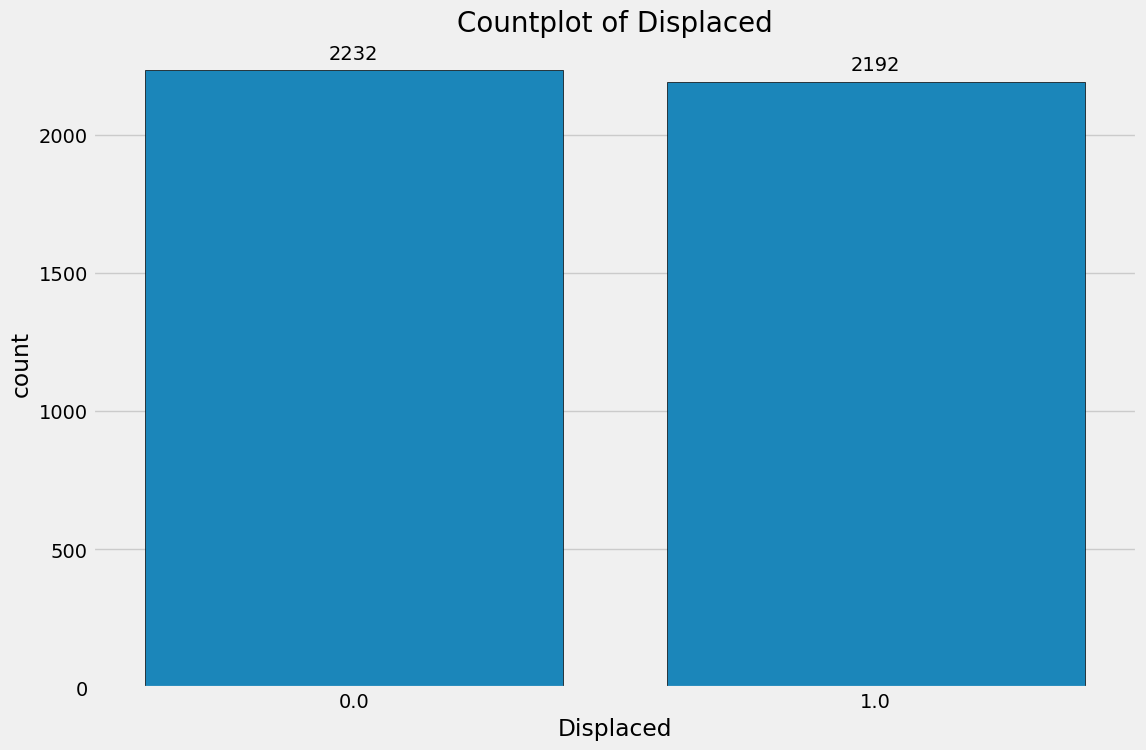

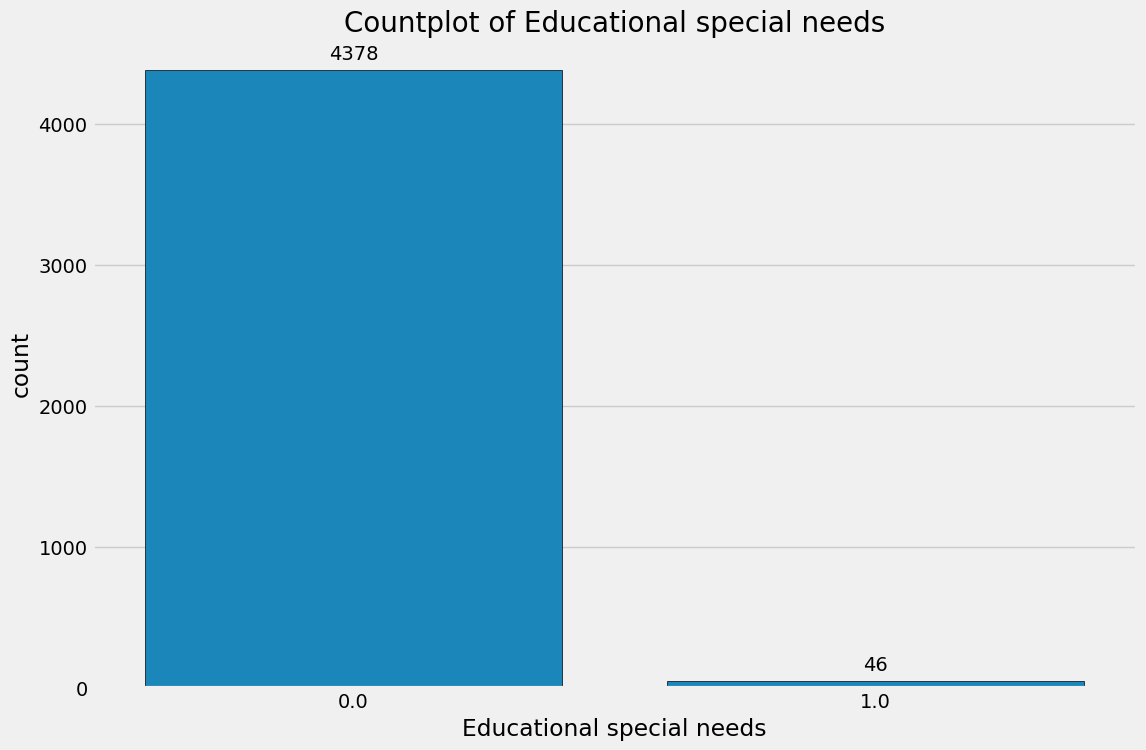

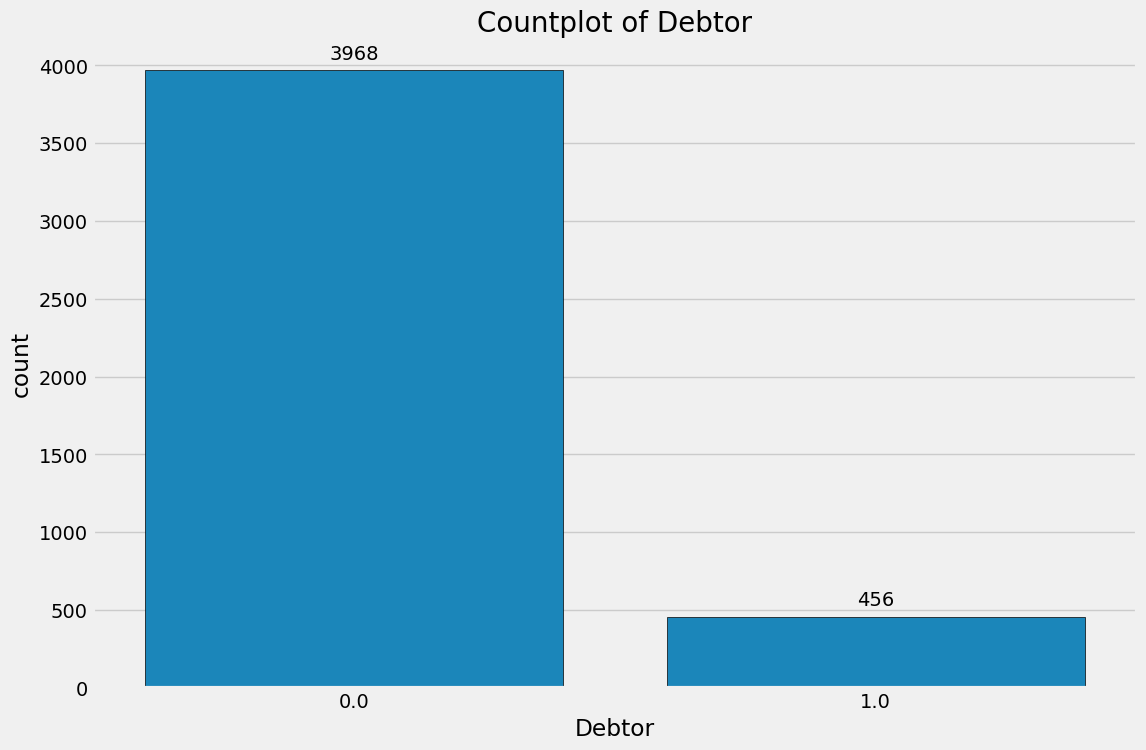

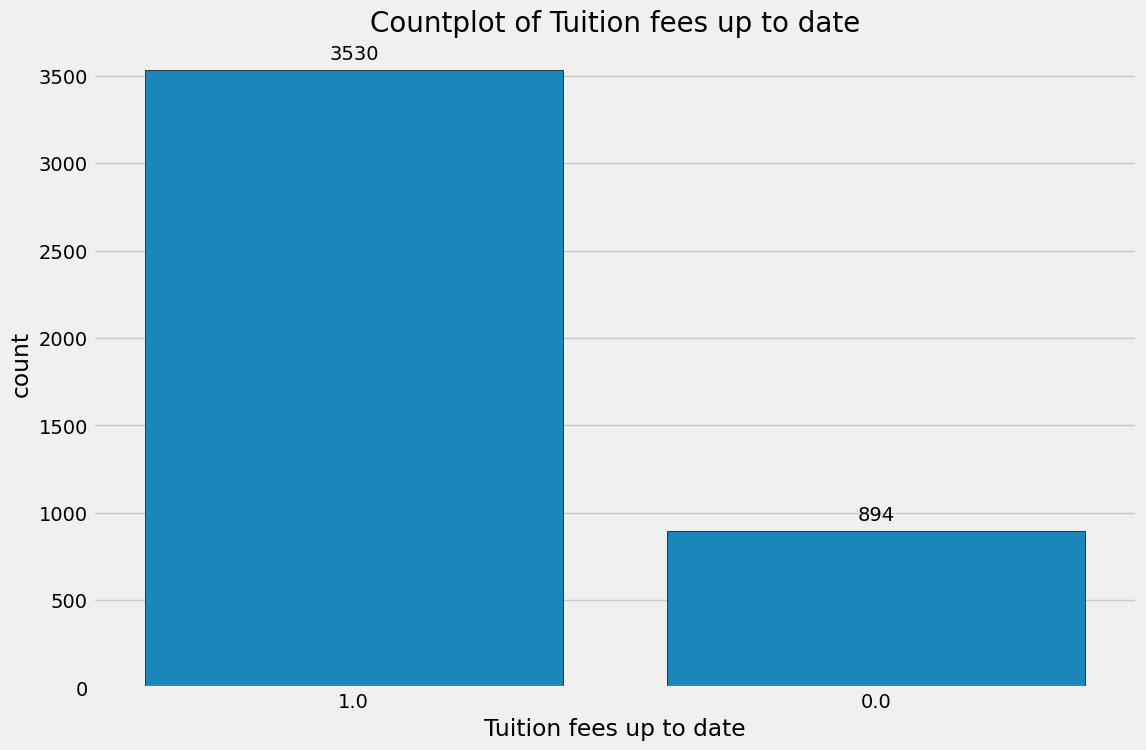

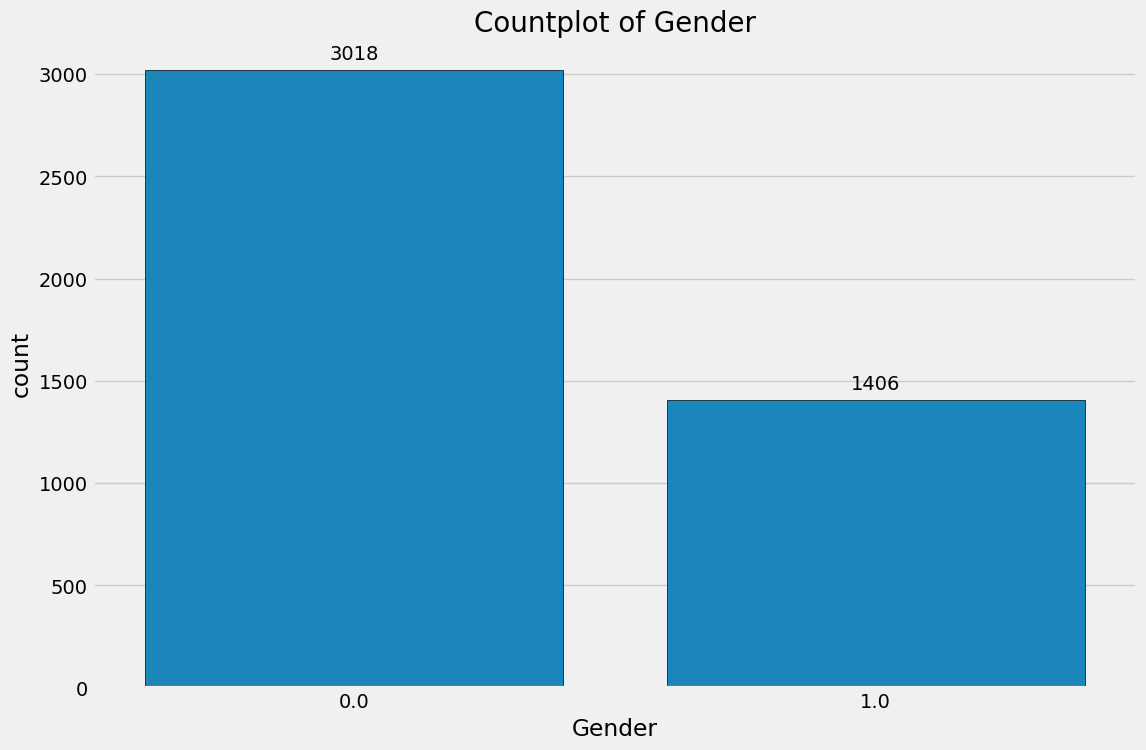

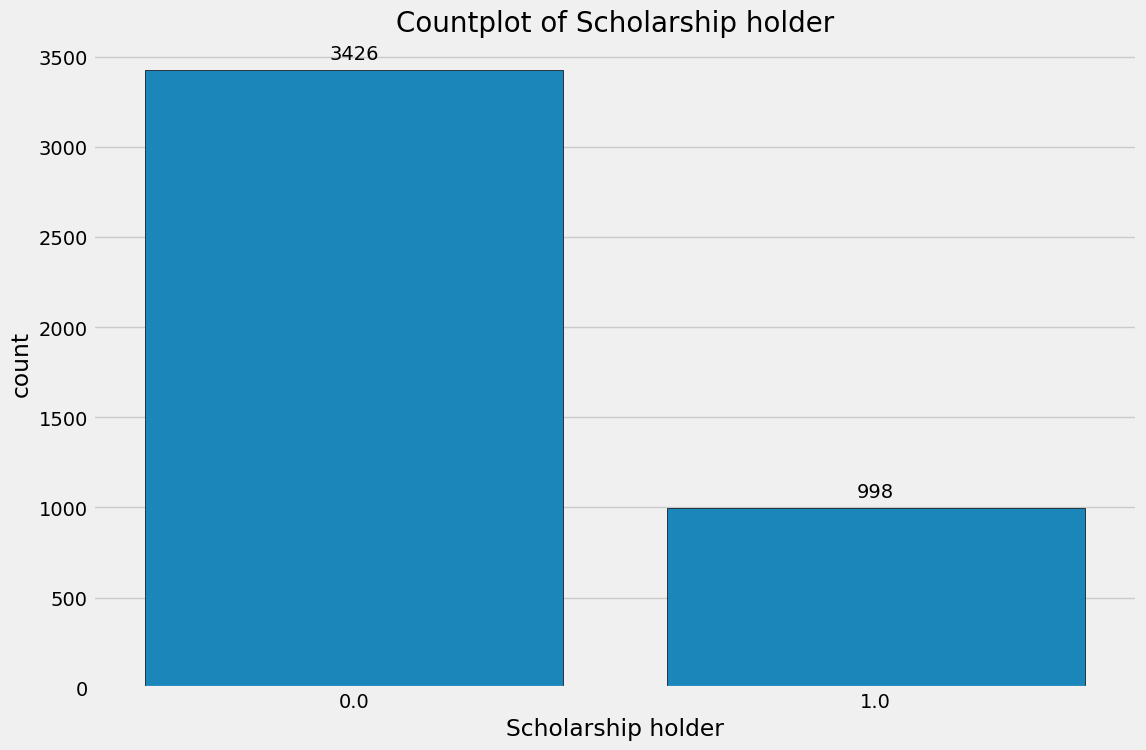

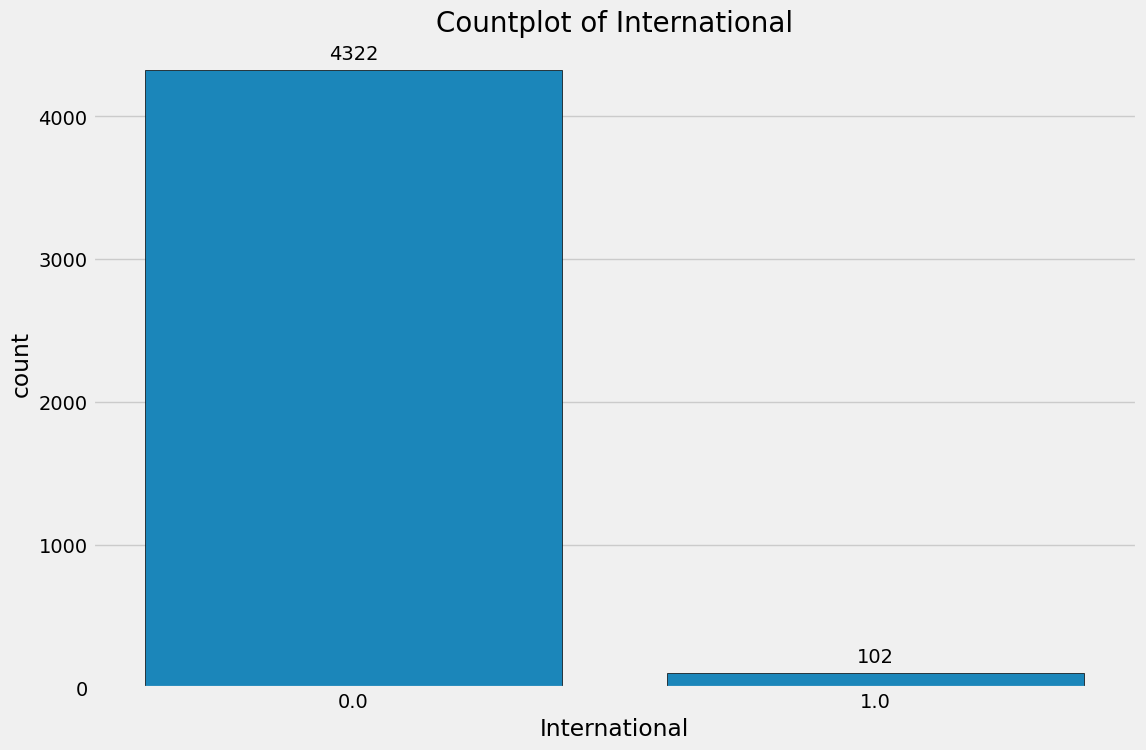

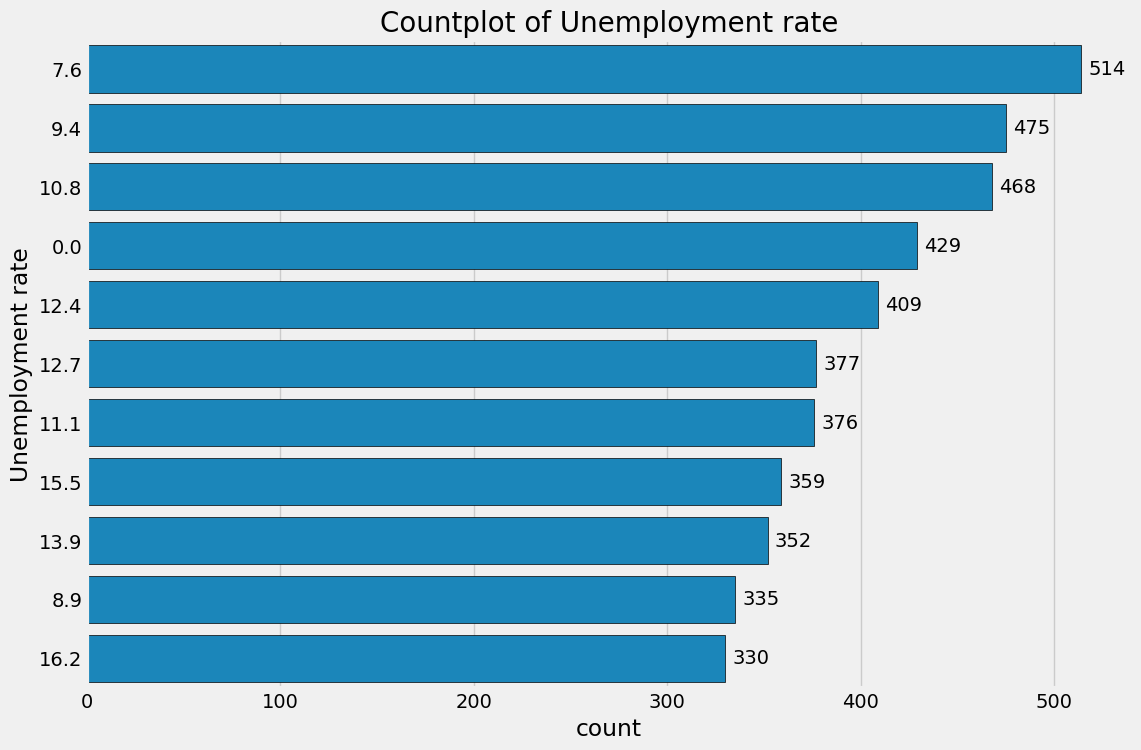

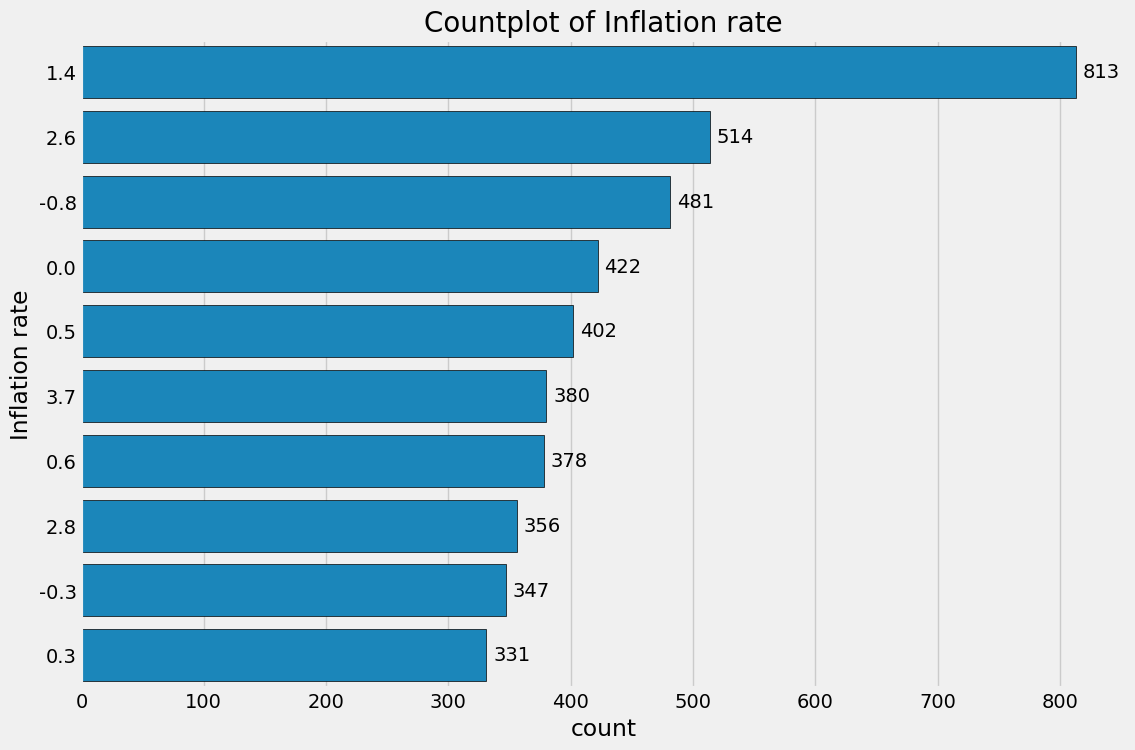

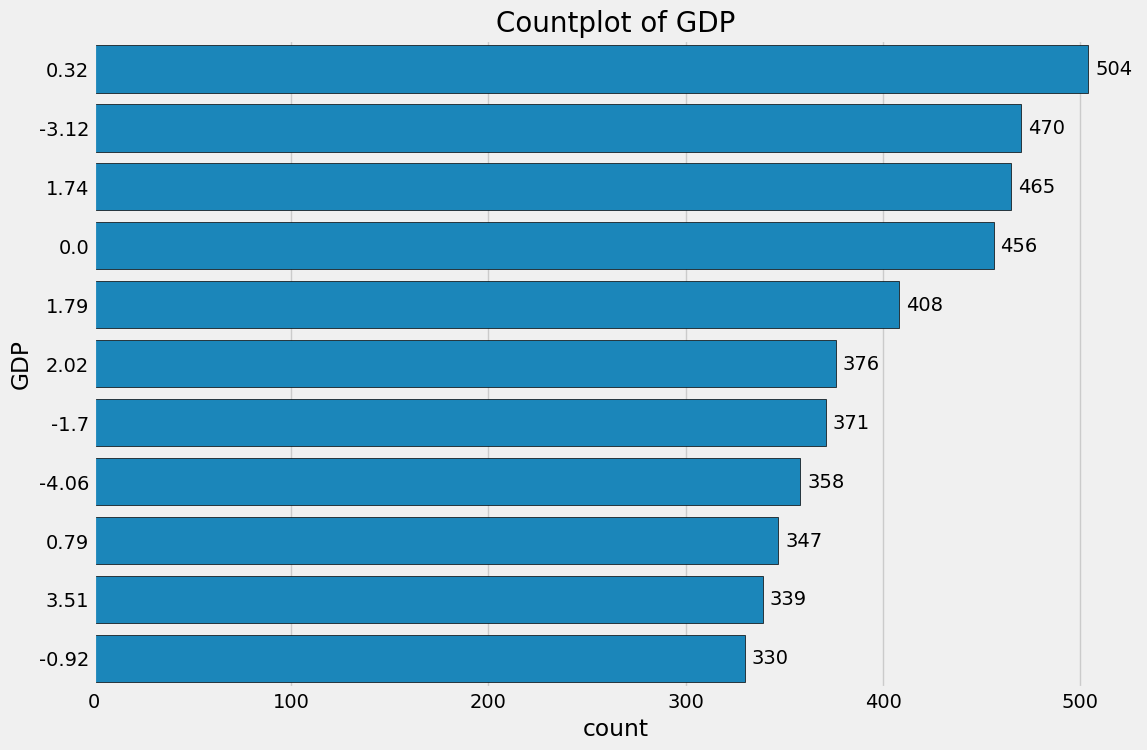

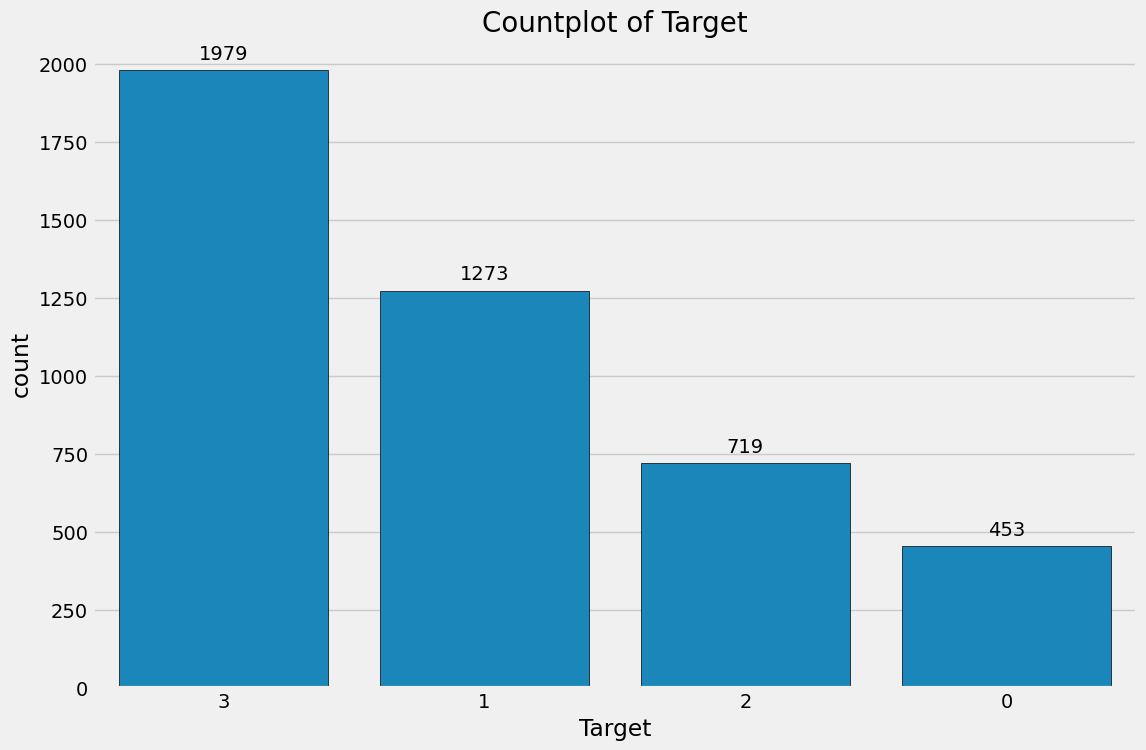

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

In [182]:
from fasteda import fast_eda
fast_eda(df)

In [163]:
xtrain,xtest,ytrain,ytest=train_test_split(X,Y,test_size=0.3,random_state=42)

In [164]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(xtrain, ytrain)

ypred_knn = knn.predict(xtest)
yprob_knn = knn.predict_proba(xtest)


In [165]:
from sklearn.linear_model import LogisticRegression

log = LogisticRegression(max_iter=3000)
log.fit(xtrain, ytrain)

ypred_log = log.predict(xtest)
yprob_log = log.predict_proba(xtest)


In [166]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)

num_classes = len(np.unique(ytrain))


if num_classes > 2:
    ytrain_fit = to_categorical(ytrain, num_classes=num_classes)
    ytest_fit = to_categorical(ytest, num_classes=num_classes)
else:
    ytrain_fit = ytrain
    ytest_fit = ytest

nn = Sequential()
nn.add(Dense(30, activation="relu", input_shape=(xtrain.shape[1],)))
nn.add(Dense(50, activation="relu"))

if num_classes == 2:
    nn.add(Dense(1, activation="sigmoid"))
    nn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
else:
    nn.add(Dense(num_classes, activation="softmax"))
    nn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history = nn.fit(
    xtrain, ytrain_fit,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


pred_nn = nn.predict(xtest)

if num_classes == 2:
    yprob_nn = pred_nn.flatten()
    ypred_nn = (yprob_nn >= 0.5).astype(int)
else:
    yprob_nn = pred_nn
    ypred_nn = np.argmax(pred_nn, axis=1)


Epoch 1/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4015 - loss: 1.3365 - val_accuracy: 0.5290 - val_loss: 1.1859
Epoch 2/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4970 - loss: 1.2148 - val_accuracy: 0.5371 - val_loss: 1.1496
Epoch 3/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5238 - loss: 1.1728 - val_accuracy: 0.5548 - val_loss: 1.1338
Epoch 4/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5332 - loss: 1.1485 - val_accuracy: 0.5548 - val_loss: 1.1269
Epoch 5/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5417 - loss: 1.1334 - val_accuracy: 0.5613 - val_loss: 1.1240
Epoch 6/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5467 - loss: 1.1224 - val_accuracy: 0.5613 - val_loss: 1.1230
Epoch 7/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5464 - loss: 1.1134 - val_accuracy: 0.5613 - val_loss: 1.1233
Epoch 8/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5482 - loss: 1.1054 - val_accuracy: 0.5565 - val_loss:

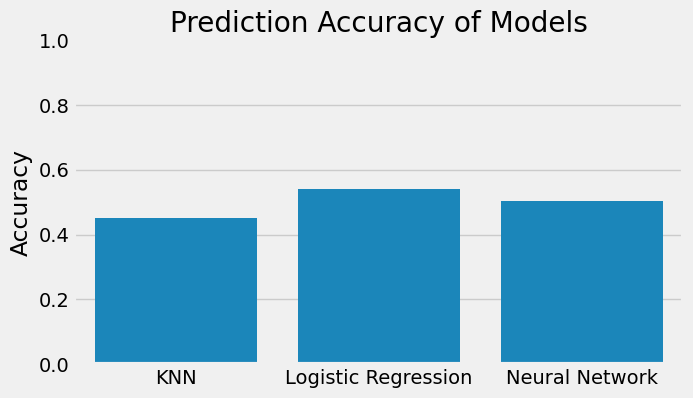

KNN Accuracy = 0.4495481927710843
Logistic Regression Accuracy = 0.5406626506024096
Neural Network Accuracy = 0.5037650602409639


In [167]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

models = {
    "KNN": (ytest, ypred_knn),
    "Logistic Regression": (ytest, ypred_log),
    "Neural Network": (ytest, ypred_nn)
}

names = []
accs = []

for name, (yt, yp) in models.items():
    names.append(name)
    accs.append(accuracy_score(yt, yp))

plt.figure(figsize=(7,4))
sns.barplot(x=names, y=accs)
plt.title("Prediction Accuracy of Models")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

for n, a in zip(names, accs):
    print(n, "Accuracy =", a)


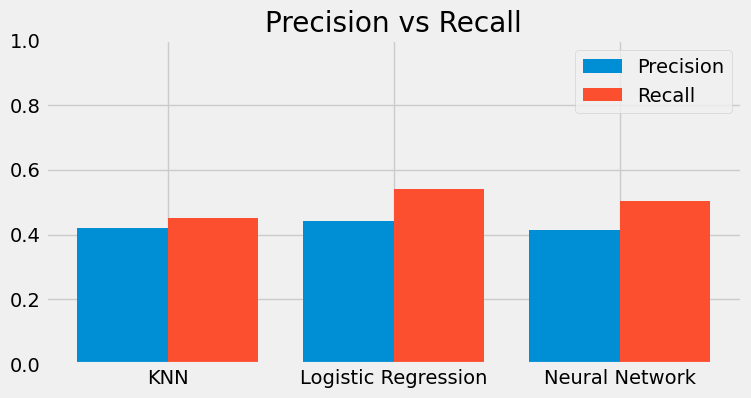

KNN Precision = 0.4211371489258355 | Recall = 0.4495481927710843
Logistic Regression Precision = 0.4412664375676543 | Recall = 0.5406626506024096
Neural Network Precision = 0.41481691605250337 | Recall = 0.5037650602409639


In [168]:
from sklearn.metrics import precision_score, recall_score

precisions = []
recalls = []

for name, (yt, yp) in models.items():
    precisions.append(precision_score(yt, yp, average="weighted", zero_division=0))
    recalls.append(recall_score(yt, yp, average="weighted", zero_division=0))

x = np.arange(len(names))

plt.figure(figsize=(8,4))
plt.bar(x - 0.2, precisions, width=0.4, label="Precision")
plt.bar(x + 0.2, recalls, width=0.4, label="Recall")
plt.xticks(x, names)
plt.ylim(0,1)
plt.title("Precision vs Recall")
plt.legend()
plt.show()

for n, p, r in zip(names, precisions, recalls):
    print(n, "Precision =", p, "| Recall =", r)


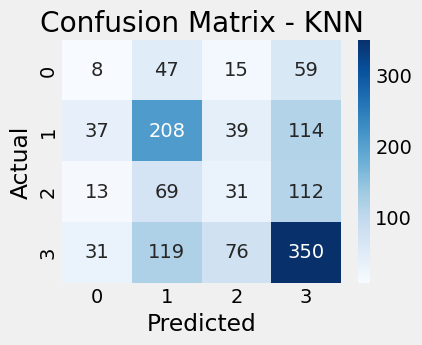


Classification Report - KNN
              precision    recall  f1-score   support

           0       0.09      0.06      0.07       129
           1       0.47      0.52      0.49       398
           2       0.19      0.14      0.16       225
           3       0.55      0.61      0.58       576

    accuracy                           0.45      1328
   macro avg       0.33      0.33      0.33      1328
weighted avg       0.42      0.45      0.43      1328



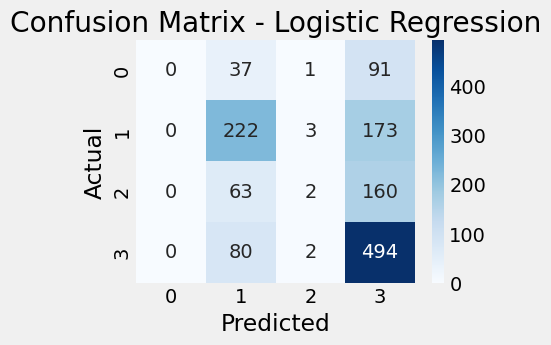


Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       129
           1       0.55      0.56      0.56       398
           2       0.25      0.01      0.02       225
           3       0.54      0.86      0.66       576

    accuracy                           0.54      1328
   macro avg       0.34      0.36      0.31      1328
weighted avg       0.44      0.54      0.46      1328



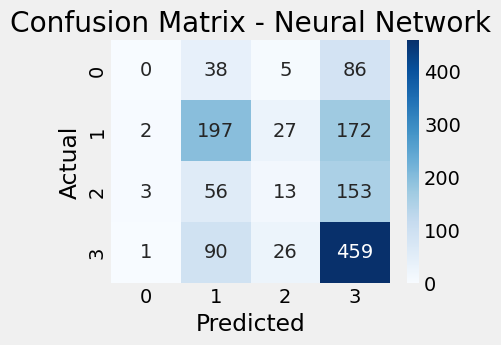


Classification Report - Neural Network
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       129
           1       0.52      0.49      0.51       398
           2       0.18      0.06      0.09       225
           3       0.53      0.80      0.63       576

    accuracy                           0.50      1328
   macro avg       0.31      0.34      0.31      1328
weighted avg       0.41      0.50      0.44      1328



In [169]:
from sklearn.metrics import confusion_matrix, classification_report

for name, (yt, yp) in models.items():
    cm = confusion_matrix(yt, yp)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix - " + name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print("\nClassification Report -", name)
    print(classification_report(yt, yp, zero_division=0))


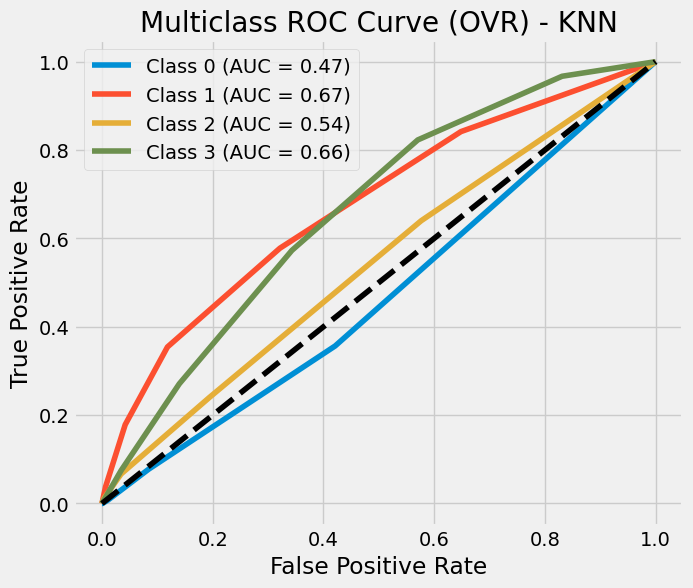

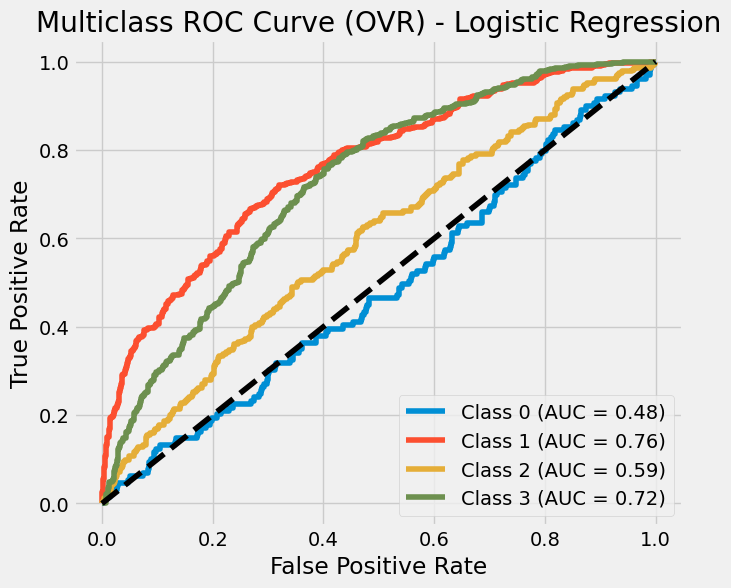

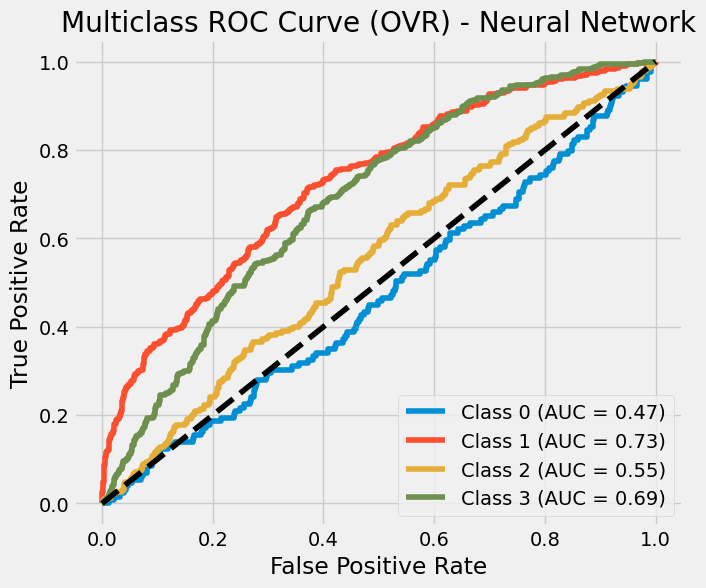

In [186]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

classes = np.unique(ytest)
ytest_bin = label_binarize(ytest, classes=classes)

models = {
    "KNN": yprob_knn,
    "Logistic Regression": yprob_log,
    "Neural Network": yprob_nn
}

for model_name, yprob in models.items():
    plt.figure(figsize=(7,6))

    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(ytest_bin[:, i], yprob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")

    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Multiclass ROC Curve (OVR) - {model_name}")
    plt.legend()
    plt.show()


In [183]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

plt.figure(figsize=(7,6))

if len(np.unique(ytest)) == 2:
    # binary: use prob of class 1
    yprob_knn_bin = yprob_knn[:, 1]
    yprob_log_bin = yprob_log[:, 1]
    yprob_nn_bin = yprob_nn

    probs = {
        "KNN": yprob_knn_bin,
        "Logistic Regression": yprob_log_bin,
        "Neural Network": yprob_nn_bin
    }

    for name, prob in probs.items():
        fpr, tpr, _ = roc_curve(ytest, prob)
        auc_score = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.2f})")
        print(name, "AUC =", roc_auc_score(ytest, prob))

    plt.plot([0,1], [0,1], "k--")
    plt.title("ROC Curve (Binary)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

else:
    # multiclass: macro AUC (OVR)
    classes = np.unique(ytest)
    ytest_bin = label_binarize(ytest, classes=classes)

    probs = {
        "KNN": yprob_knn,
        "Logistic Regression": yprob_log,
        "Neural Network": yprob_nn
    }

    for name, prob in probs.items():
        auc_macro = roc_auc_score(ytest_bin, prob, average="macro", multi_class="ovr")
        print(name, "Macro AUC (OVR) =", auc_macro)

    print("Multiclass ROC: macro AUC printed (OVR).")


KNN Macro AUC (OVR) = 0.5870688816182195
Logistic Regression Macro AUC (OVR) = 0.6410610405493239
Neural Network Macro AUC (OVR) = 0.6085248416015436
Multiclass ROC: macro AUC printed (OVR).


<Figure size 700x600 with 0 Axes>

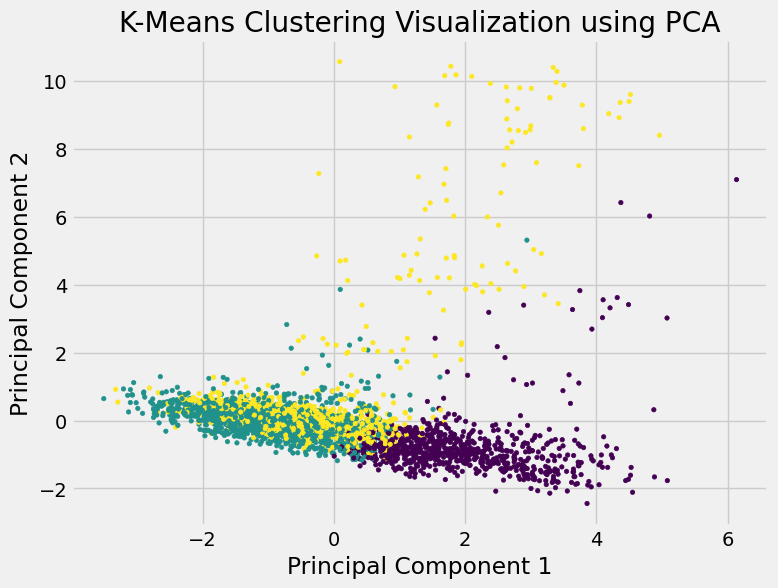

In [184]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(xtrain)
labels = kmeans.labels_#cluster labels

pca = PCA(n_components=2)
xtrain_pca = pca.fit_transform(xtrain)

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(xtrain_pca[:,0], xtrain_pca[:,1], c=labels, cmap='viridis', s=10)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering Visualization using PCA")
plt.show()


In [171]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)#run model with 2 component
xtrain_pca=pca.fit_transform(xtrain)
xtest_pca=pca.transform(xtest)

xtrain_pca


array([[-2.31114316e-01,  6.08373781e-01],
       [-1.04094692e+00,  7.97069708e-01],
       [-6.76068233e-01,  1.72366899e-03],
       ...,
       [ 2.77907600e-01, -5.43489187e-01],
       [-2.15333122e+00,  6.56386443e-01],
       [-1.19224880e+00, -3.09336771e-01]])

In [172]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(xtrain_pca, ytrain)

ypred_knn_pca = knn_pca.predict(xtest_pca)

acc_knn_pca = accuracy_score(ytest, ypred_knn_pca)
print("KNN Accuracy (with PCA):", acc_knn_pca)


KNN Accuracy (with PCA): 0.37876506024096385
